# Part 3 — Modeling and Evaluation

**Project:** Airbnb Price Prediction in Berlin  
**Unit of observation:** one Airbnb listing  
**Target:** advertised nightly price in euros after the Part 1 cleaning rule

This notebook trains reproducible regression baselines and machine-learning models, compares alternative error penalties, tests whether spatial and text-derived features add predictive value, examines sensitivity to random train/test splits, and performs error analysis.

The primary metric is **MAE** because it measures average error directly in euros and penalizes a €50 error ten times as much as a €5 error. **RMSE** is secondary because it penalizes large mistakes more strongly. **R²** is reported as a scale-free supporting measure.

In [1]:
from pathlib import Path
import copy
import json
import os
import platform
import random
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV, GroupShuffleSplit, StratifiedKFold,
    cross_validate, train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
STABILITY_SEEDS = [0, 21, 42, 84, 123]
TEST_SIZE = 0.20
N_CV_SPLITS = 3
TORCH_DEVICE = torch.device("cpu")
torch.set_num_threads(min(4, os.cpu_count() or 1))
torch.use_deterministic_algorithms(True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Python version:", platform.python_version())
print("scikit-learn version:", sklearn.__version__)
print("PyTorch version:", torch.__version__)
print("PyTorch device:", TORCH_DEVICE)

Python version: 3.14.0
scikit-learn version: 1.9.0
PyTorch version: 2.13.0+cpu
PyTorch device: cpu


In [2]:
def locate_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        modeling_path = candidate / "data" / "processed" / "modeling_dataset.csv"
        cleaned_path = candidate / "data" / "processed" / "listings_cleaned.csv"
        if modeling_path.exists() and cleaned_path.exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate both processed datasets. Open the repository root "
        "(or notebooks folder), then run notebooks/01_eda.ipynb and "
        "notebooks/02_feature_engineering.ipynb first."
    )


PROJECT_ROOT = locate_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "modeling_dataset.csv"
CLEANED_PATH = PROJECT_ROOT / "data" / "processed" / "listings_cleaned.csv"
RESULTS_PATH = PROJECT_ROOT / "data" / "processed" / "final_results.json"

print("Project root:", PROJECT_ROOT)
print("Modeling data:", DATA_PATH)
print("Cleaned source:", CLEANED_PATH)


Project root: C:\Personal Documents\Masters\Semester 2\Machine_Learning\airbnb-price-prediction-berlin
Modeling data: C:\Personal Documents\Masters\Semester 2\Machine_Learning\airbnb-price-prediction-berlin\data\processed\modeling_dataset.csv
Cleaned source: C:\Personal Documents\Masters\Semester 2\Machine_Learning\airbnb-price-prediction-berlin\data\processed\listings_cleaned.csv


## 1. Load and audit the modeling table

The identifier is retained only for traceability and is never used as a predictor. The notebook checks missingness, duplicate rows, duplicated feature columns, and the target distribution before fitting models.

In [3]:
df_raw = pd.read_csv(DATA_PATH)

# Recover host-level grouping and the few missingness states that Part 2 had
# converted to complete numeric values. These fields are used for split-aware
# preprocessing and for the unseen-host stress test; host_id is never a predictor.
source_audit = pd.read_csv(
    CLEANED_PATH,
    usecols=[
        "id", "host_id", "host_is_superhost", "host_identity_verified",
        "host_listings_count", "host_total_listings_count",
    ],
)
source_audit["host_is_superhost_was_missing"] = (
    source_audit["host_is_superhost"].eq("Unknown")
    | source_audit["host_is_superhost"].isna()
).astype(int)
source_audit["host_identity_verified_was_missing"] = (
    source_audit["host_identity_verified"].isna().astype(int)
)
source_audit["host_listings_count_was_missing"] = (
    source_audit["host_listings_count"].isna().astype(int)
)
source_audit["host_total_listings_count_was_missing"] = (
    source_audit["host_total_listings_count"].isna().astype(int)
)

source_audit = source_audit.drop(
    columns=[
        "host_is_superhost", "host_identity_verified",
        "host_listings_count", "host_total_listings_count",
    ]
)
df_raw = df_raw.merge(source_audit, on="id", how="left", validate="one_to_one")
host_groups = df_raw.pop("host_id")

print("Shape:", df_raw.shape)
print("Missing cells in the Part 2 export:", int(pd.read_csv(DATA_PATH).isna().sum().sum()))
print("Duplicate rows:", int(df_raw.duplicated().sum()))
print("Duplicate listing IDs:", int(df_raw["id"].duplicated().sum()))
print("Unique hosts:", int(host_groups.nunique()))
display(df_raw["price"].describe().to_frame("price"))


Shape: (9171, 71)
Missing cells in the Part 2 export: 0
Duplicate rows: 0
Duplicate listing IDs: 0
Unique hosts: 5222


,price
count,"9,171.000"
mean,125.848
std,81.239
min,5.000
25%,70.000
50%,103.000
75%,159.000
max,617.000


In [4]:
# Reconstruct originally missing numeric values so every model pipeline learns
# imputation statistics from its own training data rather than from the full table.
restore_missing = {
    "reviews_per_month": "reviews_per_month_was_missing",
    "review_scores_rating": "review_scores_rating_was_missing",
    "review_scores_accuracy": "review_scores_accuracy_was_missing",
    "review_scores_cleanliness": "review_scores_cleanliness_was_missing",
    "review_scores_checkin": "review_scores_checkin_was_missing",
    "review_scores_communication": "review_scores_communication_was_missing",
    "review_scores_location": "review_scores_location_was_missing",
    "review_scores_value": "review_scores_value_was_missing",
    "bathrooms_parsed": "bathrooms_parsed_was_missing",
    "bedrooms": "bedrooms_was_missing",
    "beds": "beds_was_missing",
    "host_is_superhost": "host_is_superhost_was_missing",
    "host_identity_verified": "host_identity_verified_was_missing",
    "host_listings_count": "host_listings_count_was_missing",
    "host_total_listings_count": "host_total_listings_count_was_missing",
}
for value_column, flag_column in restore_missing.items():
    df_raw.loc[df_raw[flag_column].eq(1), value_column] = np.nan

# Exact duplicate review-missing indicators carry identical information.
review_missing_flags = [
    "first_review_was_missing",
    "last_review_was_missing",
    "review_scores_rating_was_missing",
    "review_scores_accuracy_was_missing",
    "review_scores_cleanliness_was_missing",
    "review_scores_checkin_was_missing",
    "review_scores_communication_was_missing",
    "review_scores_location_was_missing",
    "review_scores_value_was_missing",
    "reviews_per_month_was_missing",
]
assert all(
    df_raw[review_missing_flags[0]].equals(df_raw[col])
    for col in review_missing_flags[1:]
), "The review-missing indicators are no longer exact duplicates; inspect Part 2."

df = df_raw.copy()
df["review_information_was_missing"] = df[review_missing_flags[0]]
df = df.drop(columns=review_missing_flags)

# Defensive checks before modeling.
assert df["price"].notna().all()
assert (df["price"] > 0).all()
assert df["id"].is_unique
assert host_groups.notna().all()
assert not np.isinf(df.select_dtypes(include=np.number).to_numpy()).any()

constant_columns = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
restored_missing_counts = df.isna().sum()
restored_missing_counts = restored_missing_counts[restored_missing_counts > 0]

print("Shape after consolidating duplicate indicators:", df.shape)
print("Restored missing values for training-only imputation:")
display(restored_missing_counts.to_frame("n_missing"))
print("Constant columns:", constant_columns or "None")


Shape after consolidating duplicate indicators: (9171, 62)
Restored missing values for training-only imputation:


,n_missing
bathrooms_parsed,5
bedrooms,46
beds,9
reviews_per_month,2026
review_scores_rating,2026
review_scores_accuracy,2026
review_scores_cleanliness,2026
review_scores_checkin,2026
review_scores_communication,2026
review_scores_location,2026


Constant columns: None


### Preprocessing scope and remaining limitations

Parts 1 and 2 create a complete numeric export before the split. To prevent those full-dataset fill values from affecting evaluation, this notebook reconstructs the relevant originally missing numeric entries from their missingness indicators (and the cleaned source table for the few host fields). Every scikit-learn pipeline and the PyTorch workflow then fits median imputation using training data only.

The 99th-percentile target restriction and the one-hot column vocabulary were still defined during Parts 1 and 2. The target restriction is treated as the study scope: the model predicts typical listings with observed positive prices up to the EDA-defined cutoff, not missing-price listings or the excluded extreme upper tail. The encoded categories are a small fixed set of room types and Berlin boroughs, but defining them before splitting remains a minor preprocessing limitation.

Hyperparameter selection, scaling, imputation, neural-network early stopping, candidate selection, and modality comparisons use training data only. The fixed test outcomes are evaluated only after the final candidate has been selected.


## 2. Define feature modalities

Location is separated into coarse borough indicators and precise spatial variables. The text modality consists of character and word counts, not TF-IDF. This distinction is important for accurate reporting.

In [5]:
TARGET = "price"
ID_COLUMN = "id"

precise_spatial_features = ["latitude", "longitude", "distance_to_center_km"]
coarse_spatial_features = [
    c for c in df.columns if c.startswith("neighbourhood_group_cleansed_")
]
text_features = [
    "name_length",
    "name_word_count",
    "description_length",
    "description_word_count",
    "neighborhood_overview_length",
    "neighborhood_overview_word_count",
]

all_predictors = [c for c in df.columns if c not in [TARGET, ID_COLUMN]]
tabular_features = [
    c for c in all_predictors
    if c not in precise_spatial_features + coarse_spatial_features + text_features
]

feature_sets = {
    "no_spatial": tabular_features + text_features,
    "coarse_location": tabular_features + text_features + coarse_spatial_features,
    "full_spatial": all_predictors,
    "without_text": [c for c in all_predictors if c not in text_features],
}

feature_group_summary = pd.DataFrame({
    "feature_group": ["Tabular", "Precise spatial", "Coarse spatial", "Simple text"],
    "n_features": [
        len(tabular_features), len(precise_spatial_features),
        len(coarse_spatial_features), len(text_features)
    ],
})
display(feature_group_summary)
print("Total predictors:", len(all_predictors))

,feature_group,n_features
0,Tabular,40
1,Precise spatial,3
2,Coarse spatial,11
3,Simple text,6


Total predictors: 60


## 3. Split strategy

A fixed 80/20 holdout split is used for the main result. Because price is continuous and right-skewed, decile bins are used **only for stratification**, helping the train and test sets retain similar price distributions. Hyperparameters are selected by three-fold stratified cross-validation within the training set. A compact, predeclared candidate set is used to reduce opportunistic overfitting and keep the notebook runnable.

In [6]:
X = df[all_predictors].copy()
y = df[TARGET].copy()
price_bins = pd.qcut(y, q=10, duplicates="drop", labels=False)

(
    X_train, X_test,
    y_train, y_test,
    bins_train, bins_test,
    hosts_train, hosts_test,
) = train_test_split(
    X, y, price_bins, host_groups,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=price_bins,
)

cv = StratifiedKFold(n_splits=N_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
cv_splits = list(cv.split(X_train, bins_train))

split_summary = pd.DataFrame({
    "set": ["Training", "Test"],
    "n": [len(y_train), len(y_test)],
    "n_unique_hosts": [hosts_train.nunique(), hosts_test.nunique()],
    "mean_price": [y_train.mean(), y_test.mean()],
    "median_price": [y_train.median(), y_test.median()],
    "std_price": [y_train.std(), y_test.std()],
})
display(split_summary)
print("Host overlap in the primary random split:", len(set(hosts_train) & set(hosts_test)))


,set,n,n_unique_hosts,mean_price,median_price,std_price
0,Training,7336,4375,125.712,103.000,80.889
1,Test,1835,1368,126.393,103.000,82.641


Host overlap in the primary random split: 521


In [7]:
def regression_metrics(y_true, y_pred) -> dict:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    abs_error = np.abs(y_true - y_pred)
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": mean_squared_error(y_true, y_pred) ** 0.5,
        "r2": r2_score(y_true, y_pred),
        "median_absolute_error": float(np.median(abs_error)),
        "within_10_eur": float(np.mean(abs_error <= 10)),
        "within_25_eur": float(np.mean(abs_error <= 25)),
        "within_50_eur": float(np.mean(abs_error <= 50)),
        "negative_predictions": int(np.sum(y_pred < 0)),
    }


def fit_and_evaluate(name, estimator, X_train, y_train, X_test, y_test):
    start = time.perf_counter()
    fitted = clone(estimator).fit(X_train, y_train)
    fit_seconds = time.perf_counter() - start
    train_pred = fitted.predict(X_train)
    test_pred = fitted.predict(X_test)
    row = {
        "model": name,
        "fit_seconds": fit_seconds,
        **{f"train_{k}": v for k, v in regression_metrics(y_train, train_pred).items()},
        **{f"test_{k}": v for k, v in regression_metrics(y_test, test_pred).items()},
    }
    return fitted, train_pred, test_pred, row

## 4. Baselines and linear models

The median baseline minimizes absolute error, while the mean baseline minimizes squared error. Reporting both connects each baseline to the loss it is optimal for. Linear Regression is the unregularized reference; Ridge tests whether coefficient shrinkage helps under multicollinearity.

In [8]:
median_baseline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("model", DummyRegressor(strategy="median")),
])
mean_baseline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("model", DummyRegressor(strategy="mean")),
])
linear_model = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("model", LinearRegression()),
])

ridge_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("model", Ridge()),
])
ridge_search = GridSearchCV(
    ridge_pipeline,
    param_grid={"model__alpha": np.logspace(-3, 4, 15)},
    scoring="neg_mean_absolute_error",
    cv=cv_splits,
    n_jobs=1,
    return_train_score=True,
)
ridge_search.fit(X_train, y_train)
best_ridge = ridge_search.best_estimator_
print("Best Ridge alpha:", ridge_search.best_params_["model__alpha"])
print("Ridge cross-validated MAE:", -ridge_search.best_score_)


Best Ridge alpha: 10.0
Ridge cross-validated MAE: 38.596671648603575


### Appendix-style Ridge tuning diagnostic

This curve uses only the predefined training cross-validation folds. The fixed test set is not involved in selecting Ridge's regularization strength.

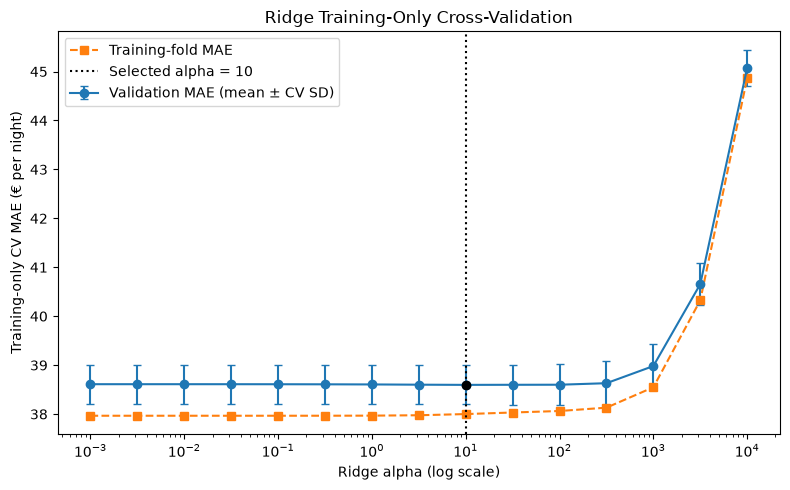

In [9]:
ridge_cv_plot = pd.DataFrame({
    "alpha": np.asarray(
        ridge_search.cv_results_["param_model__alpha"], dtype=float
    ),
    "mean_cv_mae_eur": -ridge_search.cv_results_["mean_test_score"],
    "sd_cv_mae_eur": ridge_search.cv_results_["std_test_score"],
    "mean_training_mae_eur": -ridge_search.cv_results_["mean_train_score"],
}).sort_values("alpha")

selected_ridge_alpha = float(ridge_search.best_params_["model__alpha"])
selected_ridge_row = ridge_cv_plot.loc[
    ridge_cv_plot["alpha"].eq(selected_ridge_alpha)
].iloc[0]

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    ridge_cv_plot["alpha"],
    ridge_cv_plot["mean_cv_mae_eur"],
    yerr=ridge_cv_plot["sd_cv_mae_eur"],
    marker="o",
    capsize=3,
    label="Validation MAE (mean ± CV SD)",
)
ax.plot(
    ridge_cv_plot["alpha"],
    ridge_cv_plot["mean_training_mae_eur"],
    marker="s",
    linestyle="--",
    label="Training-fold MAE",
)
ax.axvline(
    selected_ridge_alpha,
    color="black",
    linestyle=":",
    label=f"Selected alpha = {selected_ridge_alpha:g}",
)
ax.scatter(
    [selected_ridge_alpha],
    [selected_ridge_row["mean_cv_mae_eur"]],
    color="black",
    zorder=3,
)
ax.set_xscale("log")
ax.set_xlabel("Ridge alpha (log scale)")
ax.set_ylabel("Training-only CV MAE (€ per night)")
ax.set_title("Ridge Training-Only Cross-Validation")
ax.legend()
fig.tight_layout()
plt.show()

## 5. Tree-model selection

The candidate configurations are deliberately compact and fixed before viewing the test-set performance. Random Forest and Gradient Boosting capture nonlinear relationships and interactions that linear models cannot.

In [10]:
rf_candidates = [
    {
        "model__n_estimators": [150],
        "model__max_depth": [None],
        "model__min_samples_leaf": [1],
        "model__max_features": [0.7],
    },
    {
        "model__n_estimators": [200],
        "model__max_depth": [None],
        "model__min_samples_leaf": [2],
        "model__max_features": [0.7],
    },
    {
        "model__n_estimators": [200],
        "model__max_depth": [20],
        "model__min_samples_leaf": [2],
        "model__max_features": [0.7],
    },
    {
        "model__n_estimators": [250],
        "model__max_depth": [20],
        "model__min_samples_leaf": [4],
        "model__max_features": ["sqrt"],
    },
]

rf_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
])
rf_search = GridSearchCV(
    rf_pipeline,
    param_grid=rf_candidates,
    scoring="neg_mean_absolute_error",
    cv=cv_splits,
    n_jobs=1,
    return_train_score=True,
)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
best_rf_parameters = {
    key.replace("model__", ""): value
    for key, value in rf_search.best_params_.items()
}
print("Best Random Forest parameters:", best_rf_parameters)
print("Random Forest cross-validated MAE:", -rf_search.best_score_)


Best Random Forest parameters: {'max_depth': 20, 'max_features': 0.7, 'min_samples_leaf': 2, 'n_estimators': 200}
Random Forest cross-validated MAE: 31.71437389915603


In [11]:
gbr_structure_candidates = [
    {
        "model__n_estimators": [100],
        "model__learning_rate": [0.08],
        "model__max_depth": [2],
        "model__min_samples_leaf": [10],
        "model__subsample": [1.0],
    },
    {
        "model__n_estimators": [140],
        "model__learning_rate": [0.06],
        "model__max_depth": [3],
        "model__min_samples_leaf": [10],
        "model__subsample": [0.8],
    },
    {
        "model__n_estimators": [180],
        "model__learning_rate": [0.05],
        "model__max_depth": [3],
        "model__min_samples_leaf": [15],
        "model__subsample": [0.8],
    },
]

gbr_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    (
        "model",
        GradientBoostingRegressor(
            loss="squared_error",
            random_state=RANDOM_STATE,
        ),
    ),
])
gbr_structure_search = GridSearchCV(
    gbr_pipeline,
    param_grid=gbr_structure_candidates,
    scoring="neg_mean_absolute_error",
    cv=cv_splits,
    n_jobs=1,
    return_train_score=True,
)
gbr_structure_search.fit(X_train, y_train)
best_gbr_structure = {
    key.replace("model__", ""): value
    for key, value in gbr_structure_search.best_params_.items()
}
print("Best Gradient Boosting structure:", best_gbr_structure)


Best Gradient Boosting structure: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 15, 'n_estimators': 180, 'subsample': 0.8}


### Controlled loss-function comparison

Only the Gradient Boosting loss is changed while the selected tree structure remains fixed. This tests whether prediction errors should be penalized proportionally (`absolute_error`), more strongly when they are large (`squared_error`), or through a robust compromise (`huber`).

In [12]:
gbr_loss_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    (
        "model",
        GradientBoostingRegressor(
            random_state=RANDOM_STATE,
            **best_gbr_structure,
        ),
    ),
])
gbr_loss_search = GridSearchCV(
    gbr_loss_pipeline,
    param_grid={"model__loss": ["squared_error", "absolute_error", "huber"]},
    scoring="neg_mean_absolute_error",
    cv=cv_splits,
    n_jobs=1,
    return_train_score=True,
)
gbr_loss_search.fit(X_train, y_train)
best_gbr = gbr_loss_search.best_estimator_
best_gbr_loss = gbr_loss_search.best_params_["model__loss"]
print("Selected Gradient Boosting loss:", best_gbr_loss)
print("Gradient Boosting cross-validated MAE:", -gbr_loss_search.best_score_)

penalty_example = pd.DataFrame({
    "absolute_error_eur": [5, 50],
    "absolute_loss": [5, 50],
    "squared_loss": [25, 2500],
})
display(penalty_example)


Selected Gradient Boosting loss: huber
Gradient Boosting cross-validated MAE: 32.272664292235795


,absolute_error_eur,absolute_loss,squared_loss
0,5,5,25
1,50,50,2500


## 6. PyTorch multilayer perceptron

A multilayer perceptron is included as a neural-network benchmark because all predictors are numeric after Part 2 and the project course used PyTorch. Neural networks are not assumed to outperform tree ensembles on medium-sized tabular data.

The MLP uses:

- the full tabular and spatial feature set without the six simple text-length features;
- feature standardization fitted only on the current training subset;
- a `log1p` target transformation and target standardization;
- AdamW optimization, Huber (`SmoothL1`) loss, dropout, and early stopping;
- CPU execution for portability and deterministic reproduction.

Two compact architectures are compared using the same outer training folds. Each outer-fold model creates a separate inner early-stopping subset, so the outer validation fold is not used to stop training.

In [13]:
def set_torch_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


class PriceMLP(nn.Module):
    def __init__(self, n_features: int, hidden_layers: tuple[int, ...], dropout: float):
        super().__init__()
        layers = []
        previous = n_features
        for width in hidden_layers:
            layers.extend([
                nn.Linear(previous, width),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            previous = width
        layers.append(nn.Linear(previous, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x).squeeze(1)


def predict_torch_mlp(artifacts: dict, X_frame: pd.DataFrame) -> np.ndarray:
    X_imputed = artifacts["feature_imputer"].transform(X_frame)
    X_scaled = artifacts["feature_scaler"].transform(X_imputed).astype("float32")
    artifacts["model"].eval()
    with torch.no_grad():
        standardized_prediction = (
            artifacts["model"](torch.from_numpy(X_scaled).to(TORCH_DEVICE))
            .cpu()
            .numpy()
        )
    log_prediction = (
        standardized_prediction * artifacts["target_sd"]
        + artifacts["target_mean"]
    )
    return np.expm1(log_prediction)


def train_torch_mlp(
    X_fit: pd.DataFrame,
    y_fit: pd.Series,
    X_evaluate: pd.DataFrame,
    config: dict,
    seed: int,
    max_epochs: int = 240,
    patience: int = 24,
    record_detailed_history: bool = False,
) -> dict:
    set_torch_seed(seed)
    X_fit = X_fit.reset_index(drop=True)
    y_fit = y_fit.reset_index(drop=True)

    inner_bins = pd.qcut(y_fit, q=10, duplicates="drop", labels=False)
    fit_indices, stopping_indices = train_test_split(
        np.arange(len(y_fit)),
        test_size=0.12,
        random_state=seed,
        stratify=inner_bins,
    )

    feature_imputer = SimpleImputer(strategy="median").fit(X_fit.iloc[fit_indices])
    X_subtrain_imputed = feature_imputer.transform(X_fit.iloc[fit_indices])
    X_stopping_imputed = feature_imputer.transform(X_fit.iloc[stopping_indices])
    feature_scaler = StandardScaler().fit(X_subtrain_imputed)
    X_subtrain = feature_scaler.transform(X_subtrain_imputed).astype("float32")
    X_stopping = feature_scaler.transform(X_stopping_imputed).astype("float32")

    log_target = np.log1p(y_fit.iloc[fit_indices].to_numpy())
    target_mean = float(log_target.mean())
    target_sd = float(log_target.std())
    y_subtrain = ((log_target - target_mean) / target_sd).astype("float32")
    y_subtrain_raw = y_fit.iloc[fit_indices].to_numpy()
    y_stopping_raw = y_fit.iloc[stopping_indices].to_numpy()
    log_stopping_target = np.log1p(y_stopping_raw)
    y_stopping = (
        (log_stopping_target - target_mean) / target_sd
    ).astype("float32")

    model = PriceMLP(
        n_features=X_subtrain.shape[1],
        hidden_layers=tuple(config["hidden_layers"]),
        dropout=config["dropout"],
    ).to(TORCH_DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"],
    )
    loss_function = nn.SmoothL1Loss(beta=1.0)

    generator = torch.Generator().manual_seed(seed)
    loader = DataLoader(
        TensorDataset(torch.from_numpy(X_subtrain), torch.from_numpy(y_subtrain)),
        batch_size=config["batch_size"],
        shuffle=True,
        generator=generator,
        num_workers=0,
    )
    X_subtrain_tensor = torch.from_numpy(X_subtrain).to(TORCH_DEVICE)
    y_subtrain_tensor = torch.from_numpy(y_subtrain).to(TORCH_DEVICE)
    X_stopping_tensor = torch.from_numpy(X_stopping).to(TORCH_DEVICE)
    y_stopping_tensor = torch.from_numpy(y_stopping).to(TORCH_DEVICE)

    best_state = None
    best_stopping_mae = np.inf
    best_epoch = 0
    epochs_without_improvement = 0
    history = []
    start = time.perf_counter()

    for epoch in range(1, max_epochs + 1):
        model.train()
        epoch_losses = []
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(TORCH_DEVICE)
            batch_y = batch_y.to(TORCH_DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = loss_function(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()
            epoch_losses.append(float(loss.detach().cpu()))

        model.eval()
        with torch.no_grad():
            stopping_standardized_tensor = model(X_stopping_tensor)
            stopping_standardized = stopping_standardized_tensor.cpu().numpy()
        stopping_prediction = np.expm1(
            stopping_standardized * target_sd + target_mean
        )
        stopping_mae = mean_absolute_error(y_stopping_raw, stopping_prediction)

        history_row = {
            "epoch": epoch,
            "stopping_mae_eur": float(stopping_mae),
        }
        if record_detailed_history:
            with torch.no_grad():
                training_standardized_tensor = model(X_subtrain_tensor)
                training_standardized = training_standardized_tensor.cpu().numpy()
                training_huber_loss = loss_function(
                    training_standardized_tensor, y_subtrain_tensor
                ).item()
                stopping_huber_loss = loss_function(
                    stopping_standardized_tensor, y_stopping_tensor
                ).item()
            training_prediction = np.expm1(
                training_standardized * target_sd + target_mean
            )
            history_row.update({
                "training_mae_eur": float(
                    mean_absolute_error(y_subtrain_raw, training_prediction)
                ),
                "training_huber_loss": float(training_huber_loss),
                "stopping_huber_loss": float(stopping_huber_loss),
            })
        else:
            # Retain the inexpensive mini-batch objective for non-reporting runs.
            history_row["training_huber_loss"] = float(np.mean(epoch_losses))
        history.append(history_row)

        if stopping_mae < best_stopping_mae - 1e-4:
            best_stopping_mae = stopping_mae
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    # Refit from scratch on the complete outer-training data for the selected
    # number of epochs. The early-stopping subset chooses the epoch only; it is
    # not discarded from the final fit.
    set_torch_seed(seed)
    final_feature_imputer = SimpleImputer(strategy="median").fit(X_fit)
    X_full_imputed = final_feature_imputer.transform(X_fit)
    final_feature_scaler = StandardScaler().fit(X_full_imputed)
    X_full = final_feature_scaler.transform(X_full_imputed).astype("float32")
    full_log_target = np.log1p(y_fit.to_numpy())
    final_target_mean = float(full_log_target.mean())
    final_target_sd = float(full_log_target.std())
    y_full_standardized = (
        (full_log_target - final_target_mean) / final_target_sd
    ).astype("float32")

    final_model = PriceMLP(
        n_features=X_full.shape[1],
        hidden_layers=tuple(config["hidden_layers"]),
        dropout=config["dropout"],
    ).to(TORCH_DEVICE)
    final_optimizer = torch.optim.AdamW(
        final_model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"],
    )
    final_generator = torch.Generator().manual_seed(seed)
    final_loader = DataLoader(
        TensorDataset(torch.from_numpy(X_full), torch.from_numpy(y_full_standardized)),
        batch_size=config["batch_size"],
        shuffle=True,
        generator=final_generator,
        num_workers=0,
    )

    for _ in range(best_epoch):
        final_model.train()
        for batch_X, batch_y in final_loader:
            batch_X = batch_X.to(TORCH_DEVICE)
            batch_y = batch_y.to(TORCH_DEVICE)
            final_optimizer.zero_grad(set_to_none=True)
            final_loss = loss_function(final_model(batch_X), batch_y)
            final_loss.backward()
            final_optimizer.step()

    artifacts = {
        "model": final_model,
        "feature_imputer": final_feature_imputer,
        "feature_scaler": final_feature_scaler,
        "target_mean": final_target_mean,
        "target_sd": final_target_sd,
        "best_epoch": best_epoch,
        "best_stopping_mae": best_stopping_mae,
        "fit_seconds": time.perf_counter() - start,
        "history": pd.DataFrame(history),
        "history_scope": "inner training and early-stopping subsets",
        "record_detailed_history": record_detailed_history,
        "config": config,
    }
    artifacts["train_prediction"] = predict_torch_mlp(artifacts, X_fit)
    artifacts["evaluation_prediction"] = predict_torch_mlp(artifacts, X_evaluate)
    return artifacts


In [14]:
mlp_features = feature_sets["without_text"]
mlp_candidate_configs = {
    "PyTorch MLP 64-32": {
        "hidden_layers": (64, 32),
        "dropout": 0.10,
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "batch_size": 256,
    },
    "PyTorch MLP 128-64-32": {
        "hidden_layers": (128, 64, 32),
        "dropout": 0.15,
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "batch_size": 256,
    },
}

mlp_cv_rows = []
for architecture_name, config in mlp_candidate_configs.items():
    for fold, (fold_train_indices, fold_validation_indices) in enumerate(cv_splits):
        artifacts = train_torch_mlp(
            X_train.iloc[fold_train_indices][mlp_features],
            y_train.iloc[fold_train_indices],
            X_train.iloc[fold_validation_indices][mlp_features],
            config=config,
            seed=100 + fold,
            max_epochs=220,
            patience=22,
        )
        fold_prediction = artifacts["evaluation_prediction"]
        fold_metrics = regression_metrics(
            y_train.iloc[fold_validation_indices], fold_prediction
        )
        mlp_cv_rows.append({
            "architecture": architecture_name,
            "fold": fold + 1,
            "best_epoch": artifacts["best_epoch"],
            **fold_metrics,
        })

mlp_cv_runs = pd.DataFrame(mlp_cv_rows)
mlp_cv_summary = (
    mlp_cv_runs.groupby("architecture")
    .agg(
        mean_cv_mae=("mae", "mean"),
        sd_cv_mae=("mae", "std"),
        mean_cv_rmse=("rmse", "mean"),
        mean_cv_r2=("r2", "mean"),
        mean_best_epoch=("best_epoch", "mean"),
    )
    .sort_values("mean_cv_mae")
    .reset_index()
)
display(mlp_cv_summary)

selected_mlp_architecture = mlp_cv_summary.loc[0, "architecture"]
selected_mlp_config = mlp_candidate_configs[selected_mlp_architecture]
print("Selected MLP architecture:", selected_mlp_architecture)
print("The architecture is selected using training folds only.")

,architecture,mean_cv_mae,sd_cv_mae,mean_cv_rmse,mean_cv_r2,mean_best_epoch
0,PyTorch MLP 128-64-32,31.329,0.515,49.996,0.618,72.000
1,PyTorch MLP 64-32,31.554,0.303,50.575,0.609,64.333


Selected MLP architecture: PyTorch MLP 128-64-32
The architecture is selected using training folds only.


## 7. Final-candidate and target-scale selection

Because price is right-skewed, the strongest model families are compared on both the raw target and `log1p(price)`. The log transform changes the error preference: it often improves typical euro error but can underpredict expensive listings and therefore worsen RMSE.

The Random Forest is also compared with and without the six simple text-length features. **All choices in this section use only the training folds. The fixed test set is not evaluated until the next section.** The cross-validation scores are selection scores rather than unbiased final generalization estimates, because the same training folds are reused for compact hyperparameter and candidate selection.

In [15]:
raw_rf = clone(best_rf)
log_rf = TransformedTargetRegressor(
    regressor=clone(best_rf),
    func=np.log1p,
    inverse_func=np.expm1,
    check_inverse=False,
)
raw_ridge = clone(best_ridge)
log_ridge = TransformedTargetRegressor(
    regressor=clone(best_ridge),
    func=np.log1p,
    inverse_func=np.expm1,
    check_inverse=False,
)

MLP_CANDIDATE_NAME = "PyTorch MLP — log target, no text"

final_candidate_definitions = {
    "Random Forest — raw target, full features": {
        "estimator": raw_rf,
        "features": all_predictors,
        "target_scale": "raw_price",
        "text_setting": "with_text",
    },
    "Random Forest — log target, full features": {
        "estimator": log_rf,
        "features": all_predictors,
        "target_scale": "log1p_price",
        "text_setting": "with_text",
    },
    "Random Forest — raw target, no text": {
        "estimator": clone(best_rf),
        "features": feature_sets["without_text"],
        "target_scale": "raw_price",
        "text_setting": "without_text",
    },
    "Random Forest — log target, no text": {
        "estimator": TransformedTargetRegressor(
            regressor=clone(best_rf),
            func=np.log1p,
            inverse_func=np.expm1,
            check_inverse=False,
        ),
        "features": feature_sets["without_text"],
        "target_scale": "log1p_price",
        "text_setting": "without_text",
    },
    "Gradient Boosting — selected loss, full features": {
        "estimator": clone(best_gbr),
        "features": all_predictors,
        "target_scale": "raw_price",
        "text_setting": "with_text",
    },
    "Ridge — raw target, full features": {
        "estimator": raw_ridge,
        "features": all_predictors,
        "target_scale": "raw_price",
        "text_setting": "with_text",
    },
    "Ridge — log target, full features": {
        "estimator": log_ridge,
        "features": all_predictors,
        "target_scale": "log1p_price",
        "text_setting": "with_text",
    },
}

candidate_cv_rows = []
for candidate_name, spec in final_candidate_definitions.items():
    result = cross_validate(
        spec["estimator"],
        X_train[spec["features"]],
        y_train,
        cv=cv_splits,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2",
        },
        n_jobs=1,
        return_train_score=True,
    )
    candidate_cv_rows.append({
        "candidate": candidate_name,
        "target_scale": spec["target_scale"],
        "text_setting": spec["text_setting"],
        "mean_cv_mae": -result["test_mae"].mean(),
        "sd_cv_mae": result["test_mae"].std(ddof=1),
        "mean_cv_rmse": -result["test_rmse"].mean(),
        "mean_cv_r2": result["test_r2"].mean(),
        "mean_train_mae": -result["train_mae"].mean(),
    })

candidate_cv_rows.append({
    "candidate": MLP_CANDIDATE_NAME,
    "target_scale": "log1p_price",
    "text_setting": "without_text",
    "mean_cv_mae": mlp_cv_summary.loc[0, "mean_cv_mae"],
    "sd_cv_mae": mlp_cv_summary.loc[0, "sd_cv_mae"],
    "mean_cv_rmse": mlp_cv_summary.loc[0, "mean_cv_rmse"],
    "mean_cv_r2": mlp_cv_summary.loc[0, "mean_cv_r2"],
    "mean_train_mae": np.nan,
})

final_candidate_cv = (
    pd.DataFrame(candidate_cv_rows)
    .sort_values("mean_cv_mae")
    .reset_index(drop=True)
)
display(final_candidate_cv)

selected_candidate_name = final_candidate_cv.loc[0, "candidate"]
if selected_candidate_name == MLP_CANDIDATE_NAME:
    selected_candidate = {
        "features": mlp_features,
        "target_scale": "log1p_price",
        "text_setting": "without_text",
        "estimator": None,
    }
else:
    selected_candidate = final_candidate_definitions[selected_candidate_name]

print("Selected by lowest training cross-validated MAE:", selected_candidate_name)

,candidate,target_scale,text_setting,mean_cv_mae,sd_cv_mae,mean_cv_rmse,mean_cv_r2,mean_train_mae
0,"Random Forest — log target, no text",log1p_price,without_text,30.297,0.552,49.677,0.623,13.848
1,"Random Forest — log target, full features",log1p_price,with_text,30.471,0.507,49.970,0.618,13.667
2,"PyTorch MLP — log target, no text",log1p_price,without_text,31.329,0.515,49.996,0.618,NaN
3,"Random Forest — raw target, no text",raw_price,without_text,31.570,0.520,49.004,0.633,13.971
4,"Random Forest — raw target, full features",raw_price,with_text,31.714,0.499,49.146,0.631,13.758
5,"Gradient Boosting — selected loss, full features",raw_price,with_text,32.273,0.353,50.716,0.607,29.759
6,"Ridge — log target, full features",log1p_price,with_text,37.043,0.249,58.786,0.472,36.541
7,"Ridge — raw target, full features",raw_price,with_text,38.597,0.489,56.258,0.516,38.000


Selected by lowest training cross-validated MAE: Random Forest — log target, no text


## 8. Main holdout comparison

The candidate above is fixed before this section is run. The held-out test set is now evaluated once for the final candidate and for the predeclared reference models. Test results are reported for comparison, but they do not change the selected model.

In [16]:
selected_estimators = {
    "Median baseline": median_baseline,
    "Mean baseline": mean_baseline,
    "Linear Regression": linear_model,
    "Ridge — raw target, full features": best_ridge,
    "Random Forest — raw target, full features": best_rf,
    "Gradient Boosting — selected loss, full features": best_gbr,
}

fitted_models = {}
predictions = {}
comparison_rows = []

for name, estimator in selected_estimators.items():
    fitted, train_pred, test_pred, row = fit_and_evaluate(
        name, estimator, X_train, y_train, X_test, y_test
    )
    fitted_models[name] = fitted
    predictions[name] = test_pred
    comparison_rows.append(row)

mlp_main_artifacts = train_torch_mlp(
    X_train[mlp_features],
    y_train,
    X_test[mlp_features],
    config=selected_mlp_config,
    seed=RANDOM_STATE,
    max_epochs=300,
    patience=30,
    record_detailed_history=True,
)
mlp_train_prediction = mlp_main_artifacts["train_prediction"]
mlp_test_prediction = mlp_main_artifacts["evaluation_prediction"]

# Summarize the selected MLP directly from an instantiated architecture.
mlp_summary_model = PriceMLP(
    n_features=len(mlp_features),
    hidden_layers=tuple(selected_mlp_config["hidden_layers"]),
    dropout=selected_mlp_config["dropout"],
)
mlp_linear_layers = [
    layer for layer in mlp_summary_model.network if isinstance(layer, nn.Linear)
]
mlp_dropout_layers = [
    layer for layer in mlp_summary_model.network if isinstance(layer, nn.Dropout)
]
mlp_activation_names = sorted({
    layer.__class__.__name__
    for layer in mlp_summary_model.network
    if isinstance(layer, nn.ReLU)
})
mlp_trainable_parameters = sum(
    parameter.numel()
    for parameter in mlp_summary_model.parameters()
    if parameter.requires_grad
)
mlp_architecture_summary = pd.DataFrame([{
    "architecture": selected_mlp_architecture,
    "input_features": int(mlp_linear_layers[0].in_features),
    "hidden_layer_widths": [
        int(layer.out_features) for layer in mlp_linear_layers[:-1]
    ],
    "output_dimension": int(mlp_linear_layers[-1].out_features),
    "activation": ", ".join(mlp_activation_names),
    "dropout": [float(layer.p) for layer in mlp_dropout_layers][0],
    "optimizer": torch.optim.AdamW.__name__,
    "learning_rate": float(selected_mlp_config["learning_rate"]),
    "weight_decay": float(selected_mlp_config["weight_decay"]),
    "batch_size": int(selected_mlp_config["batch_size"]),
    "loss": "SmoothL1Loss (Huber, beta=1.0)",
    "target_transformation": "log1p(price), then training-set standardization",
    "total_trainable_parameters": int(mlp_trainable_parameters),
}])
display(mlp_architecture_summary)
mlp_main_row = {
    "model": MLP_CANDIDATE_NAME,
    "fit_seconds": mlp_main_artifacts["fit_seconds"],
    **{
        f"train_{key}": value
        for key, value in regression_metrics(y_train, mlp_train_prediction).items()
    },
    **{
        f"test_{key}": value
        for key, value in regression_metrics(y_test, mlp_test_prediction).items()
    },
}
comparison_rows.append(mlp_main_row)
predictions[MLP_CANDIDATE_NAME] = mlp_test_prediction

final_features = selected_candidate["features"]
X_train_final = X_train[final_features]
X_test_final = X_test[final_features]

if selected_candidate_name == MLP_CANDIDATE_NAME:
    final_model = mlp_main_artifacts
    final_train_pred = mlp_train_prediction
    final_pred = mlp_test_prediction
    final_row = mlp_main_row
else:
    final_model, final_train_pred, final_pred, final_row = fit_and_evaluate(
        selected_candidate_name,
        selected_candidate["estimator"],
        X_train_final,
        y_train,
        X_test_final,
        y_test,
    )

comparison_rows.append(final_row)
final_model_name = selected_candidate_name
final_abs_error = np.abs(y_test.to_numpy() - final_pred)

model_comparison_final = (
    pd.DataFrame(comparison_rows)
    .drop_duplicates(subset=["model"], keep="last")
    .sort_values("test_mae")
    .reset_index(drop=True)
)

display(model_comparison_final[[
    "model", "train_mae", "test_mae", "test_rmse", "test_r2",
    "test_median_absolute_error", "test_within_25_eur", "test_within_50_eur",
    "test_negative_predictions", "fit_seconds"
]])
print("Final model selected from training CV:", final_model_name)
print("Main test metrics:", regression_metrics(y_test, final_pred))

,architecture,input_features,hidden_layer_widths,output_dimension,activation,dropout,optimizer,learning_rate,weight_decay,batch_size,loss,target_transformation,total_trainable_parameters
0,PyTorch MLP 128-64-32,54,"[128, 64, 32]",1,ReLU,0.150,AdamW,0.001,0.000,256,"SmoothL1Loss (Huber, beta=1.0)","log1p(price), then training-set standardization",17409


,model,train_mae,test_mae,test_rmse,test_r2,test_median_absolute_error,test_within_25_eur,test_within_50_eur,test_negative_predictions,fit_seconds
0,"Random Forest — log target, no text",13.556,29.586,49.244,0.645,17.490,0.632,0.844,0,3.377
1,"PyTorch MLP — log target, no text",24.231,30.104,48.782,0.651,18.305,0.620,0.834,0,28.241
2,"Random Forest — raw target, full features",13.396,30.855,48.323,0.658,20.292,0.582,0.837,0,6.836
3,"Gradient Boosting — selected loss, full features",30.363,32.134,50.872,0.621,21.354,0.569,0.822,0,9.094
4,Linear Regression,38.053,38.229,55.526,0.548,28.068,0.451,0.753,7,0.144
5,"Ridge — raw target, full features",38.070,38.266,55.557,0.548,28.042,0.451,0.753,6,0.107
6,Median baseline,56.843,57.450,85.866,-0.080,40.000,0.325,0.619,0,0.073
7,Mean baseline,59.659,60.316,82.621,-0.000,49.288,0.241,0.506,0,0.059


Final model selected from training CV: Random Forest — log target, no text
Main test metrics: {'mae': 29.58612796820596, 'rmse': 49.24378805683623, 'r2': 0.6447358404814243, 'median_absolute_error': 17.48968049157041, 'within_10_eur': 0.3198910081743869, 'within_25_eur': 0.6316076294277929, 'within_50_eur': 0.8435967302452316, 'negative_predictions': 0}


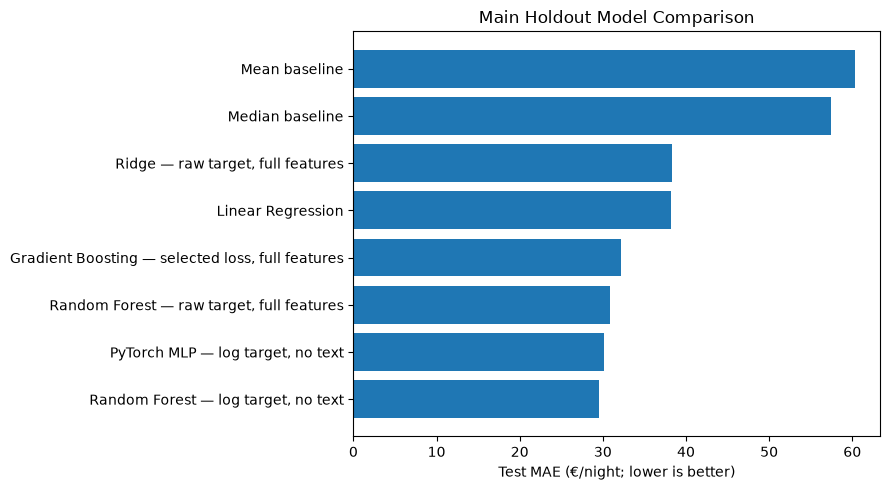

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_data = model_comparison_final.sort_values("test_mae", ascending=True)
ax.barh(plot_data["model"], plot_data["test_mae"])
ax.set_xlabel("Test MAE (€/night; lower is better)")
ax.set_title("Main Holdout Model Comparison")
fig.tight_layout()
plt.show()

### MLP optimization history

These curves belong to the **inner training and early-stopping subsets used to select the epoch**. Training and stopping MAE are both shown in euros per night, while the two Huber curves share the standardized `log1p(price)` loss scale. After the epoch is selected, the reported MLP is refitted from scratch on the complete outer-training set for that number of epochs.

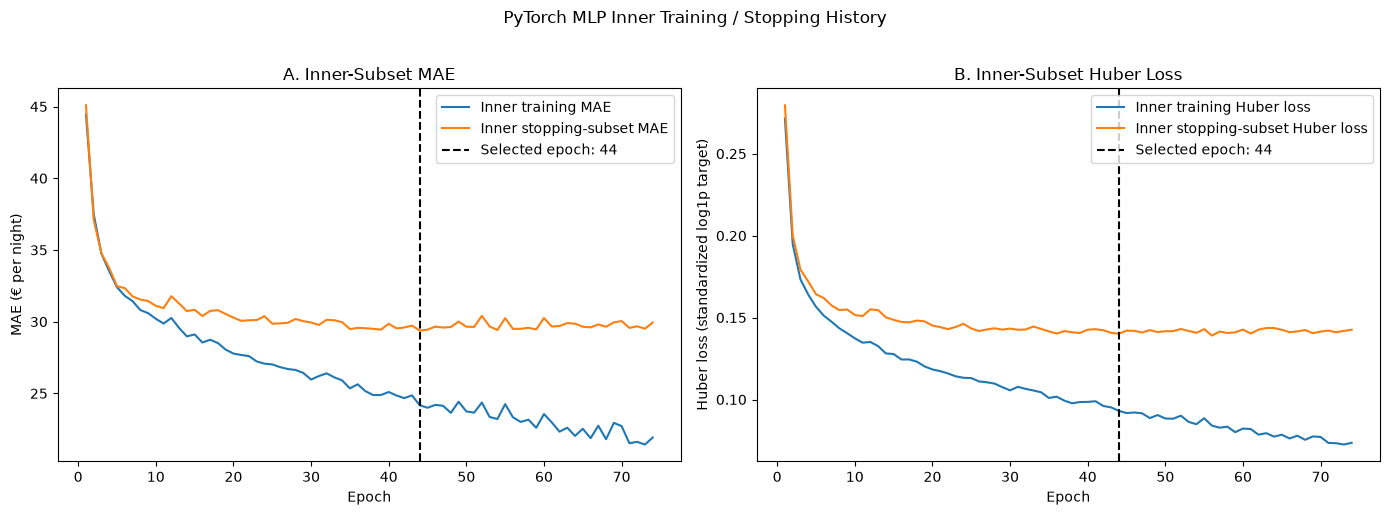

Best stopping-subset MAE (€ per night): 29.38111332082586
Selected epoch: 44


In [18]:
mlp_history = mlp_main_artifacts["history"]
required_history_columns = {
    "epoch",
    "training_mae_eur",
    "stopping_mae_eur",
    "training_huber_loss",
    "stopping_huber_loss",
}
missing_history_columns = required_history_columns.difference(mlp_history.columns)
assert not missing_history_columns, (
    f"Detailed MLP history is missing: {sorted(missing_history_columns)}"
)

mlp_best_epoch = int(mlp_main_artifacts["best_epoch"])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    mlp_history["epoch"],
    mlp_history["training_mae_eur"],
    label="Inner training MAE",
)
axes[0].plot(
    mlp_history["epoch"],
    mlp_history["stopping_mae_eur"],
    label="Inner stopping-subset MAE",
)
axes[0].axvline(
    mlp_best_epoch,
    color="black",
    linestyle="--",
    label=f"Selected epoch: {mlp_best_epoch}",
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MAE (€ per night)")
axes[0].set_title("A. Inner-Subset MAE")
axes[0].legend()

axes[1].plot(
    mlp_history["epoch"],
    mlp_history["training_huber_loss"],
    label="Inner training Huber loss",
)
axes[1].plot(
    mlp_history["epoch"],
    mlp_history["stopping_huber_loss"],
    label="Inner stopping-subset Huber loss",
)
axes[1].axvline(
    mlp_best_epoch,
    color="black",
    linestyle="--",
    label=f"Selected epoch: {mlp_best_epoch}",
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Huber loss (standardized log1p target)")
axes[1].set_title("B. Inner-Subset Huber Loss")
axes[1].legend()

fig.suptitle("PyTorch MLP Inner Training / Stopping History", y=1.02)
fig.tight_layout()
plt.show()

print("Best stopping-subset MAE (€ per night):", mlp_main_artifacts["best_stopping_mae"])
print("Selected epoch:", mlp_best_epoch)

## 9. Stability across random train/test splits

Five predetermined seeds are used with the selected hyperparameters fixed. This is a sensitivity analysis, not a second hyperparameter search. A model difference smaller than seed-to-seed variation should not be described as decisive.

These repeated splits are a robustness check for the already selected configurations, not a nested or fully independent estimate of the complete model-selection process.

In [19]:
def repeated_holdout_results(models, feature_columns, seeds=STABILITY_SEEDS):
    rows = []
    X_full = df[feature_columns]
    y_full = df[TARGET]
    bins_full = pd.qcut(y_full, q=10, duplicates="drop", labels=False)

    for seed in seeds:
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_full, y_full,
            test_size=TEST_SIZE,
            random_state=seed,
            stratify=bins_full,
        )
        for name, estimator in models.items():
            fitted = clone(estimator).fit(X_tr, y_tr)
            pred = fitted.predict(X_te)
            rows.append({"seed": seed, "model": name, **regression_metrics(y_te, pred)})
    return pd.DataFrame(rows)

stability_models = {
    "Median baseline": median_baseline,
    "Mean baseline": mean_baseline,
    "Linear Regression": linear_model,
    "Ridge — raw target, full features": best_ridge,
    "Random Forest — raw target, full features": best_rf,
    "Gradient Boosting — selected loss, full features": best_gbr,
}
stability_runs = repeated_holdout_results(stability_models, all_predictors)
mlp_stability_rows = []
X_mlp_full = df[mlp_features]
y_full = df[TARGET]
bins_full = pd.qcut(y_full, q=10, duplicates="drop", labels=False)

for seed in STABILITY_SEEDS:
    train_indices, test_indices = train_test_split(
        np.arange(len(df)),
        test_size=TEST_SIZE,
        random_state=seed,
        stratify=bins_full,
    )
    artifacts = train_torch_mlp(
        X_mlp_full.iloc[train_indices],
        y_full.iloc[train_indices],
        X_mlp_full.iloc[test_indices],
        config=selected_mlp_config,
        seed=seed,
        max_epochs=300,
        patience=30,
    )
    mlp_stability_rows.append({
        "seed": seed,
        "model": "PyTorch MLP — log target, no text",
        **regression_metrics(
            y_full.iloc[test_indices], artifacts["evaluation_prediction"]
        ),
    })

mlp_stability_runs = pd.DataFrame(mlp_stability_rows)
stability_runs = pd.concat([stability_runs, mlp_stability_runs], ignore_index=True)

stability_summary = (
    stability_runs.groupby("model")
    .agg(
        mean_mae=("mae", "mean"),
        sd_mae=("mae", "std"),
        mean_rmse=("rmse", "mean"),
        sd_rmse=("rmse", "std"),
        mean_r2=("r2", "mean"),
        sd_r2=("r2", "std"),
        mean_within_25=("within_25_eur", "mean"),
        mean_within_50=("within_50_eur", "mean"),
    )
    .sort_values("mean_mae")
    .reset_index()
)
display(stability_summary)

,model,mean_mae,sd_mae,mean_rmse,sd_rmse,mean_r2,sd_r2,mean_within_25,mean_within_50
0,"PyTorch MLP — log target, no text",30.366,0.303,48.385,0.538,0.646,0.015,0.610,0.831
1,"Random Forest — raw target, full features",30.492,0.598,47.712,1.121,0.656,0.011,0.588,0.834
2,"Gradient Boosting — selected loss, full features",31.758,0.603,50.143,1.287,0.620,0.007,0.574,0.826
3,Linear Regression,38.169,0.589,55.124,1.081,0.541,0.013,0.447,0.751
4,"Ridge — raw target, full features",38.193,0.585,55.145,1.086,0.541,0.013,0.447,0.750
5,Median baseline,57.157,0.813,84.584,2.447,-0.080,0.001,0.323,0.617
6,Mean baseline,59.971,0.735,81.394,2.334,-0.000,0.000,0.239,0.507


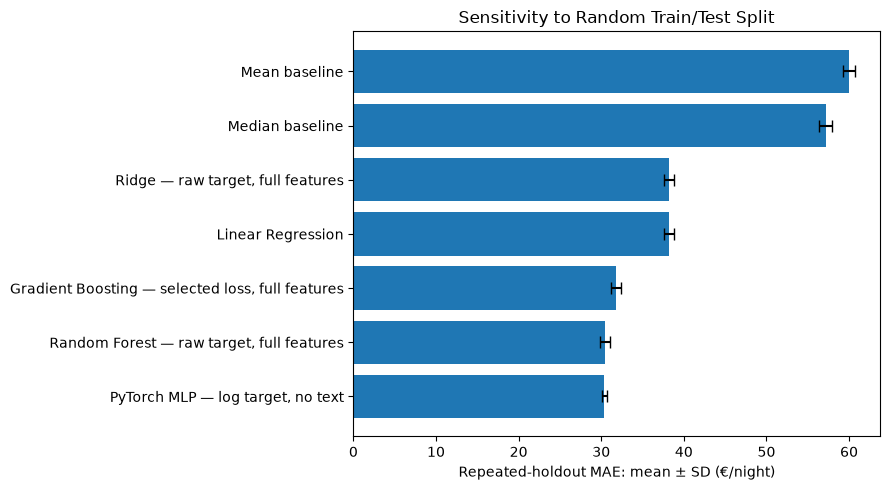

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_data = stability_summary.sort_values("mean_mae", ascending=True)
ax.barh(plot_data["model"], plot_data["mean_mae"], xerr=plot_data["sd_mae"], capsize=4)
ax.set_xlabel("Repeated-holdout MAE: mean ± SD (€/night)")
ax.set_title("Sensitivity to Random Train/Test Split")
fig.tight_layout()
plt.show()

### Selected-candidate stability

The already selected candidate is rerun across the same five predetermined splits. This is a sensitivity check for that fixed configuration, not nested validation of the complete selection procedure.

In [21]:
if selected_candidate_name == MLP_CANDIDATE_NAME:
    selected_candidate_stability_runs = mlp_stability_runs.rename(
        columns={"model": "candidate"}
    )
else:
    selected_candidate_stability_runs = repeated_holdout_results(
        {selected_candidate_name: selected_candidate["estimator"]},
        selected_candidate["features"],
    ).rename(columns={"model": "candidate"})

selected_candidate_stability = (
    selected_candidate_stability_runs.groupby("candidate")
    .agg(
        mean_mae=("mae", "mean"),
        sd_mae=("mae", "std"),
        mean_rmse=("rmse", "mean"),
        sd_rmse=("rmse", "std"),
        mean_r2=("r2", "mean"),
        mean_within_25=("within_25_eur", "mean"),
        mean_within_50=("within_50_eur", "mean"),
    )
    .reset_index()
)
display(selected_candidate_stability)

,candidate,mean_mae,sd_mae,mean_rmse,sd_rmse,mean_r2,mean_within_25,mean_within_50
0,"Random Forest — log target, no text",29.316,0.288,48.593,0.947,0.643,0.628,0.842


## 10. Generalization to previously unseen hosts

The primary split is listing-level and therefore permits the same host to appear in both training and test data. The following **secondary stress test** uses group-based splits with zero host overlap. It evaluates the already selected model configuration; it is not a second independent model-selection benchmark, because the configuration was chosen using the primary training workflow.


,split,n_train_listings,n_test_listings,n_train_hosts,n_test_hosts,host_overlap,test_mean_price,mae,rmse,r2,median_absolute_error,within_10_eur,within_25_eur,within_50_eur,negative_predictions
0,1,7279,1892,4177,1045,0,133.571,36.930,58.465,0.572,23.224,0.254,0.531,0.781,0
1,2,7501,1670,4177,1045,0,129.752,33.339,52.326,0.612,21.446,0.265,0.560,0.810,0
2,3,7410,1761,4177,1045,0,127.683,33.334,54.902,0.597,20.042,0.288,0.572,0.808,0
3,4,7300,1871,4177,1045,0,124.985,34.465,52.535,0.577,22.204,0.232,0.555,0.797,0
4,5,7340,1831,4177,1045,0,121.616,34.183,52.848,0.567,22.724,0.235,0.541,0.798,0


,model,mean_mae,sd_mae,mean_rmse,sd_rmse,mean_r2,mean_within_25,mean_within_50
0,"Random Forest — log target, no text",34.450,1.475,54.215,2.588,0.585,0.552,0.799


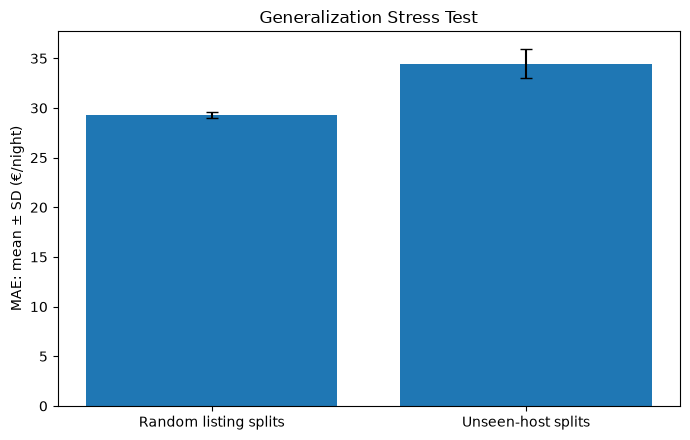

In [22]:
group_splitter = GroupShuffleSplit(
    n_splits=len(STABILITY_SEEDS),
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

host_generalization_rows = []
selected_group_features = selected_candidate["features"]

for split_number, (train_indices, test_indices) in enumerate(
    group_splitter.split(
        df[selected_group_features],
        df[TARGET],
        groups=host_groups,
    ),
    start=1,
):
    group_X_train = df.iloc[train_indices][selected_group_features]
    group_X_test = df.iloc[test_indices][selected_group_features]
    group_y_train = df.iloc[train_indices][TARGET]
    group_y_test = df.iloc[test_indices][TARGET]
    group_train_hosts = host_groups.iloc[train_indices]
    group_test_hosts = host_groups.iloc[test_indices]

    host_overlap = len(set(group_train_hosts) & set(group_test_hosts))
    assert host_overlap == 0

    if selected_candidate_name == MLP_CANDIDATE_NAME:
        group_artifacts = train_torch_mlp(
            group_X_train,
            group_y_train,
            group_X_test,
            config=selected_mlp_config,
            seed=STABILITY_SEEDS[split_number - 1],
            max_epochs=300,
            patience=30,
        )
        group_prediction = group_artifacts["evaluation_prediction"]
    else:
        group_model = clone(selected_candidate["estimator"]).fit(
            group_X_train,
            group_y_train,
        )
        group_prediction = group_model.predict(group_X_test)

    host_generalization_rows.append({
        "split": split_number,
        "n_train_listings": len(train_indices),
        "n_test_listings": len(test_indices),
        "n_train_hosts": group_train_hosts.nunique(),
        "n_test_hosts": group_test_hosts.nunique(),
        "host_overlap": host_overlap,
        "test_mean_price": group_y_test.mean(),
        **regression_metrics(group_y_test, group_prediction),
    })

host_generalization_runs = pd.DataFrame(host_generalization_rows)
host_generalization_summary = pd.DataFrame({
    "model": [selected_candidate_name],
    "mean_mae": [host_generalization_runs["mae"].mean()],
    "sd_mae": [host_generalization_runs["mae"].std(ddof=1)],
    "mean_rmse": [host_generalization_runs["rmse"].mean()],
    "sd_rmse": [host_generalization_runs["rmse"].std(ddof=1)],
    "mean_r2": [host_generalization_runs["r2"].mean()],
    "mean_within_25": [host_generalization_runs["within_25_eur"].mean()],
    "mean_within_50": [host_generalization_runs["within_50_eur"].mean()],
})

display(host_generalization_runs)
display(host_generalization_summary)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(
    ["Random listing splits", "Unseen-host splits"],
    [
        selected_candidate_stability.loc[0, "mean_mae"],
        host_generalization_summary.loc[0, "mean_mae"],
    ],
    yerr=[
        selected_candidate_stability.loc[0, "sd_mae"],
        host_generalization_summary.loc[0, "sd_mae"],
    ],
    capsize=4,
)
ax.set_ylabel("MAE: mean ± SD (€/night)")
ax.set_title("Generalization Stress Test")
fig.tight_layout()
plt.show()


## 11. Spatial-feature ablation

Three location settings are compared:

1. **No spatial information:** no coordinates, distance, or borough indicators.
2. **Coarse location:** borough indicators only.
3. **Full spatial information:** borough indicators, coordinates, and distance to the centre.

The same selected estimators and seeds are used so that location is the controlled change.

In [23]:
ablation_models = {
    "Ridge Regression": best_ridge,
    "Random Forest — log target": TransformedTargetRegressor(
        regressor=clone(best_rf),
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    ),
}

# The final Random Forest candidate excludes simple text features. Its spatial
# ablation therefore keeps text excluded in all three location settings.
spatial_features_by_model = {
    "Ridge Regression": {
        "no_spatial": feature_sets["no_spatial"],
        "coarse_location": feature_sets["coarse_location"],
        "full_spatial": all_predictors,
    },
    "Random Forest — log target": {
        "no_spatial": tabular_features,
        "coarse_location": tabular_features + coarse_spatial_features,
        "full_spatial": feature_sets["without_text"],
    },
}

spatial_rows = []
for model_name, estimator in ablation_models.items():
    for setting, columns in spatial_features_by_model[model_name].items():
        result = repeated_holdout_results({model_name: estimator}, columns)
        result["spatial_setting"] = setting
        spatial_rows.append(result)

spatial_runs = pd.concat(spatial_rows, ignore_index=True)
spatial_ablation = (
    spatial_runs.groupby(["model", "spatial_setting"])
    .agg(
        mean_mae=("mae", "mean"),
        sd_mae=("mae", "std"),
        mean_rmse=("rmse", "mean"),
        mean_r2=("r2", "mean"),
        mean_within_25=("within_25_eur", "mean"),
        mean_within_50=("within_50_eur", "mean"),
    )
    .reset_index()
)
display(spatial_ablation.sort_values(["model", "mean_mae"]))

,model,spatial_setting,mean_mae,sd_mae,mean_rmse,mean_r2,mean_within_25,mean_within_50
1,Random Forest — log target,full_spatial,29.316,0.288,48.593,0.643,0.628,0.842
0,Random Forest — log target,coarse_location,30.837,0.689,50.111,0.621,0.610,0.828
2,Random Forest — log target,no_spatial,31.368,0.642,50.610,0.613,0.600,0.825
4,Ridge Regression,full_spatial,38.193,0.585,55.145,0.541,0.447,0.750
3,Ridge Regression,coarse_location,38.732,0.593,55.870,0.529,0.443,0.743
5,Ridge Regression,no_spatial,39.459,0.543,56.930,0.510,0.444,0.739


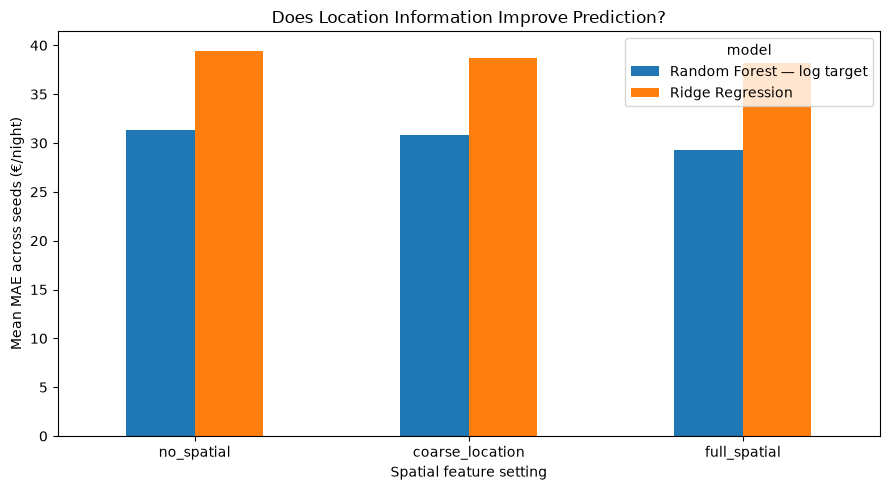

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
pivot = spatial_ablation.pivot(index="spatial_setting", columns="model", values="mean_mae")
pivot.loc[["no_spatial", "coarse_location", "full_spatial"]].plot(kind="bar", ax=ax)
ax.set_ylabel("Mean MAE across seeds (€/night)")
ax.set_xlabel("Spatial feature setting")
ax.set_title("Does Location Information Improve Prediction?")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
plt.show()

## 12. Text-feature ablation

The project evaluates three data modalities: tabular listing attributes, spatial information, and six quantities derived from listing text. The current text representation contains only character lengths and word counts; it does not capture the semantic meaning of the text.

The ablation compares Ridge and a log-target Random Forest with and without these six summaries. It tests this specific representation, not the value of semantic text in general. If the text summaries do not improve training-based validation performance, excluding them from the selected model is evidence-based feature selection rather than a failure to evaluate the text modality. The selected model can therefore use tabular and spatial information while the complete project still documents a controlled three-modality experiment.

In [25]:
text_rows = []
for setting, columns in {
    "without_text": feature_sets["without_text"],
    "with_text": all_predictors,
}.items():
    result = repeated_holdout_results(ablation_models, columns)
    result["text_setting"] = setting
    text_rows.append(result)

text_runs = pd.concat(text_rows, ignore_index=True)
text_ablation = (
    text_runs.groupby(["model", "text_setting"])
    .agg(
        mean_mae=("mae", "mean"),
        sd_mae=("mae", "std"),
        mean_rmse=("rmse", "mean"),
        mean_r2=("r2", "mean"),
    )
    .reset_index()
)
display(text_ablation.sort_values(["model", "mean_mae"]))

,model,text_setting,mean_mae,sd_mae,mean_rmse,mean_r2
1,Random Forest — log target,without_text,29.316,0.288,48.593,0.643
0,Random Forest — log target,with_text,29.366,0.367,48.764,0.641
2,Ridge Regression,with_text,38.193,0.585,55.145,0.541
3,Ridge Regression,without_text,38.409,0.638,55.413,0.536


## 13. Loss-function stability

The loss-only Gradient Boosting comparison is repeated over the same five seeds. The evaluation metrics remain MAE, RMSE, and R² in euros regardless of the internal training loss.

In [26]:
loss_models = {
    loss: Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        (
            "model",
            GradientBoostingRegressor(
                random_state=RANDOM_STATE,
                loss=loss,
                **best_gbr_structure,
            ),
        ),
    ])
    for loss in ["squared_error", "absolute_error", "huber"]
}
loss_runs = repeated_holdout_results(loss_models, all_predictors)
loss_comparison = (
    loss_runs.groupby("model")
    .agg(
        mean_mae=("mae", "mean"),
        sd_mae=("mae", "std"),
        mean_rmse=("rmse", "mean"),
        sd_rmse=("rmse", "std"),
        mean_r2=("r2", "mean"),
        mean_within_25=("within_25_eur", "mean"),
        mean_within_50=("within_50_eur", "mean"),
    )
    .sort_values("mean_mae")
    .reset_index()
    .rename(columns={"model": "loss"})
)
display(loss_comparison)


,loss,mean_mae,sd_mae,mean_rmse,sd_rmse,mean_r2,mean_within_25,mean_within_50
0,huber,31.758,0.603,50.143,1.287,0.620,0.574,0.826
1,squared_error,32.170,0.676,48.844,1.047,0.640,0.551,0.816
2,absolute_error,32.242,0.558,52.234,1.370,0.588,0.586,0.820


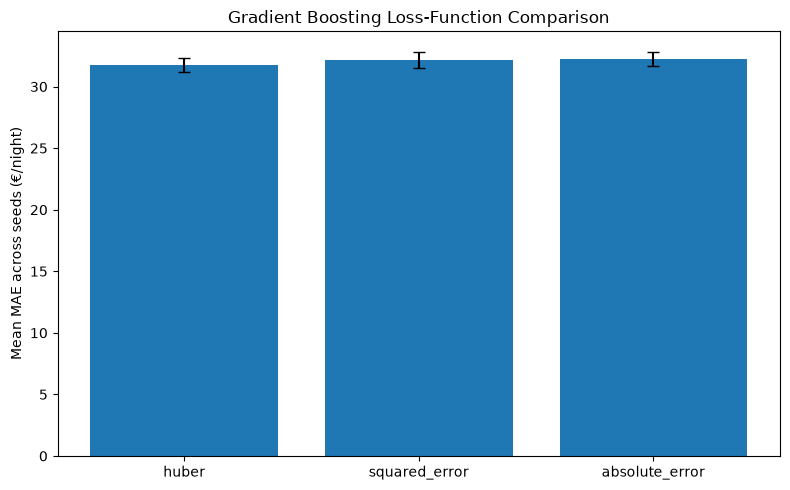

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(loss_comparison["loss"], loss_comparison["mean_mae"], yerr=loss_comparison["sd_mae"], capsize=4)
ax.set_ylabel("Mean MAE across seeds (€/night)")
ax.set_title("Gradient Boosting Loss-Function Comparison")
fig.tight_layout()
plt.show()

## 14. Final-model diagnostics

The final candidate was selected by training-only cross-validated MAE before the fixed test set was evaluated. The following diagnostics describe the resulting held-out predictions. They are not used to revise or reselect the model.

The homogeneity-of-variance assumption used for classical linear-model inference is not a fitting assumption of Random Forest regression. Nevertheless, unequal residual spread remains important: it reveals price ranges in which point predictions are less reliable. Because observed prices are nonnegative, an original-scale residual defined as `actual - predicted` has the mathematical lower bound `residual >= -prediction`; this contributes to a triangular boundary at low fitted values. Any additional widening and systematic displacement from zero indicate changing error variance or calibration across the price range.

The selected model is trained on `log1p(price)` because that target scale produced the lowest training cross-validated MAE. Back-transformation returns predictions to euros, where multiplicative variation naturally becomes larger absolute variation for expensive listings. The original-price and log-scale residual views below distinguish absolute-euro error from relative error behavior.

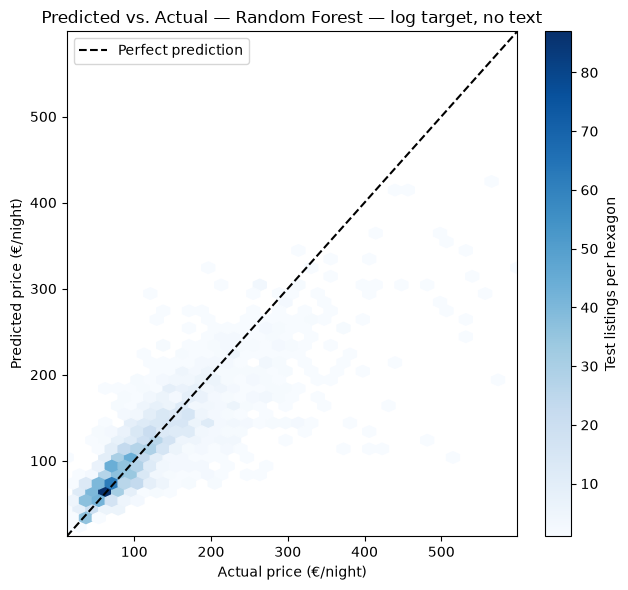

In [28]:
fig, ax = plt.subplots(figsize=(6.5, 6))
hexbin = ax.hexbin(
    y_test,
    final_pred,
    gridsize=35,
    mincnt=1,
    cmap="Blues",
)
lims = [min(y_test.min(), final_pred.min()), max(y_test.max(), final_pred.max())]
ax.plot(lims, lims, linestyle="--", color="black", label="Perfect prediction")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Actual price (€/night)")
ax.set_ylabel("Predicted price (€/night)")
ax.set_title(f"Predicted vs. Actual — {final_model_name}")
ax.legend()
colorbar = fig.colorbar(hexbin, ax=ax)
colorbar.set_label("Test listings per hexagon")
fig.tight_layout()
plt.show()

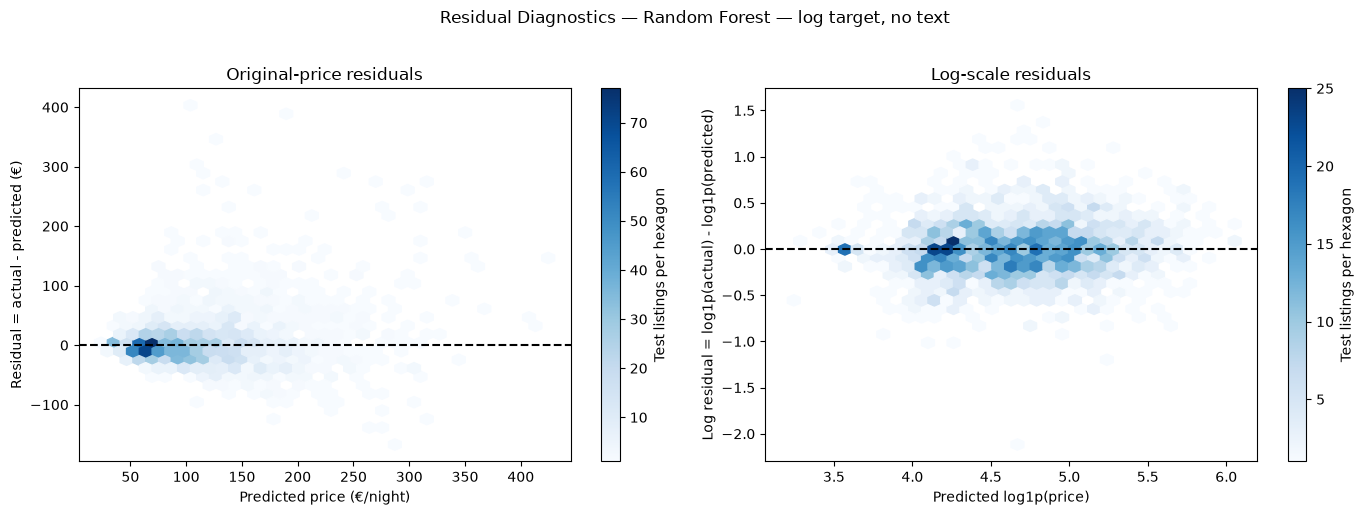

In [29]:
residuals = y_test.to_numpy() - final_pred
log_actual = np.log1p(y_test.to_numpy())
log_predicted = np.log1p(np.clip(final_pred, a_min=0, a_max=None))
log_residuals = log_actual - log_predicted

final_holdout_predictions = pd.DataFrame({
    "actual_price": y_test.to_numpy(),
    "predicted_price": final_pred,
    "residual": residuals,
    "absolute_error": final_abs_error,
    "log_actual_price": log_actual,
    "log_predicted_price": log_predicted,
    "log_residual": log_residuals,
})
assert len(final_holdout_predictions) == len(y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

original_hexbin = axes[0].hexbin(
    final_pred,
    residuals,
    gridsize=35,
    mincnt=1,
    cmap="Blues",
)
axes[0].axhline(0, linestyle="--", color="black")
axes[0].set_xlabel("Predicted price (€/night)")
axes[0].set_ylabel("Residual = actual - predicted (€)")
axes[0].set_title("Original-price residuals")
original_colorbar = fig.colorbar(original_hexbin, ax=axes[0])
original_colorbar.set_label("Test listings per hexagon")

log_hexbin = axes[1].hexbin(
    log_predicted,
    log_residuals,
    gridsize=35,
    mincnt=1,
    cmap="Blues",
)
axes[1].axhline(0, linestyle="--", color="black")
axes[1].set_xlabel("Predicted log1p(price)")
axes[1].set_ylabel("Log residual = log1p(actual) - log1p(predicted)")
axes[1].set_title("Log-scale residuals")
log_colorbar = fig.colorbar(log_hexbin, ax=axes[1])
log_colorbar.set_label("Test listings per hexagon")

fig.suptitle(f"Residual Diagnostics — {final_model_name}", y=1.02)
fig.tight_layout()
plt.show()

### Calibration and residual spread by prediction decile

The held-out predictions are divided into ten equally sized groups according to predicted price. For each group, the table reports calibration, signed bias, residual spread, and MAE. A positive signed residual means that the model underpredicts on average.

This is a descriptive post-selection diagnostic. It quantifies the cone-shaped pattern but is not used to change the selected model.

,prediction_decile,n,mean_actual_price,mean_predicted_price,mean_signed_residual,residual_sd,mae
0,1,184,47.076,48.054,-0.978,14.120,10.128
1,2,183,61.995,63.262,-1.268,17.870,12.823
2,3,184,78.043,72.632,5.412,28.287,19.121
3,4,183,92.208,85.123,7.085,32.702,21.669
4,5,184,98.332,98.530,-0.198,33.082,22.459
5,6,183,121.137,112.783,8.353,57.681,31.469
6,7,183,140.945,128.940,12.005,52.659,33.938
7,8,184,162.158,147.792,14.366,51.929,36.907
8,9,183,187.268,177.105,10.162,65.802,46.399
9,10,184,274.620,248.085,26.535,80.350,60.938


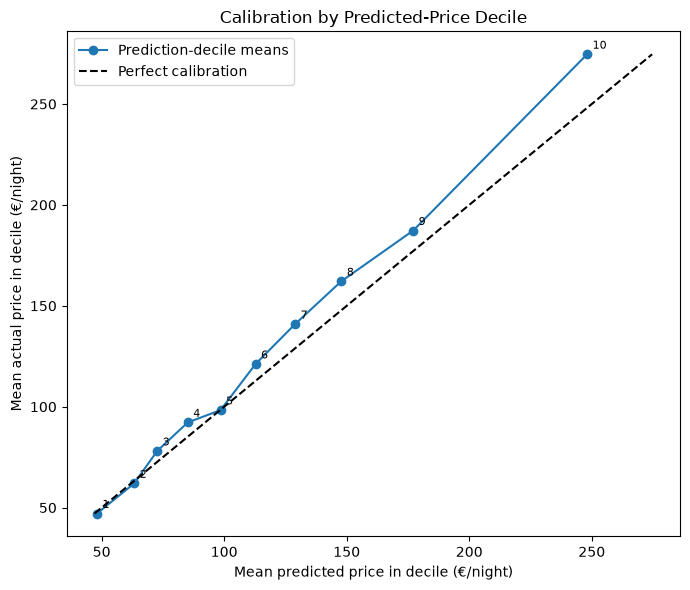

In [30]:
diagnostic_frame = final_holdout_predictions.copy()
diagnostic_frame["prediction_decile"] = pd.qcut(
    diagnostic_frame["predicted_price"],
    q=10,
    labels=False,
    duplicates="drop",
) + 1

residual_bin_summary = (
    diagnostic_frame.groupby("prediction_decile", observed=False)
    .agg(
        n=("residual", "size"),
        mean_actual_price=("actual_price", "mean"),
        mean_predicted_price=("predicted_price", "mean"),
        mean_signed_residual=("residual", "mean"),
        residual_sd=("residual", "std"),
        mae=("absolute_error", "mean"),
    )
    .reset_index()
)
calibration_by_decile = residual_bin_summary[[
    "prediction_decile",
    "n",
    "mean_predicted_price",
    "mean_actual_price",
    "mean_signed_residual",
]].copy()

display(residual_bin_summary)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(
    calibration_by_decile["mean_predicted_price"],
    calibration_by_decile["mean_actual_price"],
    marker="o",
    label="Prediction-decile means",
)
calibration_limits = [
    min(
        calibration_by_decile["mean_predicted_price"].min(),
        calibration_by_decile["mean_actual_price"].min(),
    ),
    max(
        calibration_by_decile["mean_predicted_price"].max(),
        calibration_by_decile["mean_actual_price"].max(),
    ),
]
ax.plot(
    calibration_limits,
    calibration_limits,
    linestyle="--",
    color="black",
    label="Perfect calibration",
)
for row in calibration_by_decile.itertuples(index=False):
    ax.annotate(
        str(int(row.prediction_decile)),
        (row.mean_predicted_price, row.mean_actual_price),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )
ax.set_xlabel("Mean predicted price in decile (€/night)")
ax.set_ylabel("Mean actual price in decile (€/night)")
ax.set_title("Calibration by Predicted-Price Decile")
ax.legend()
fig.tight_layout()
plt.show()

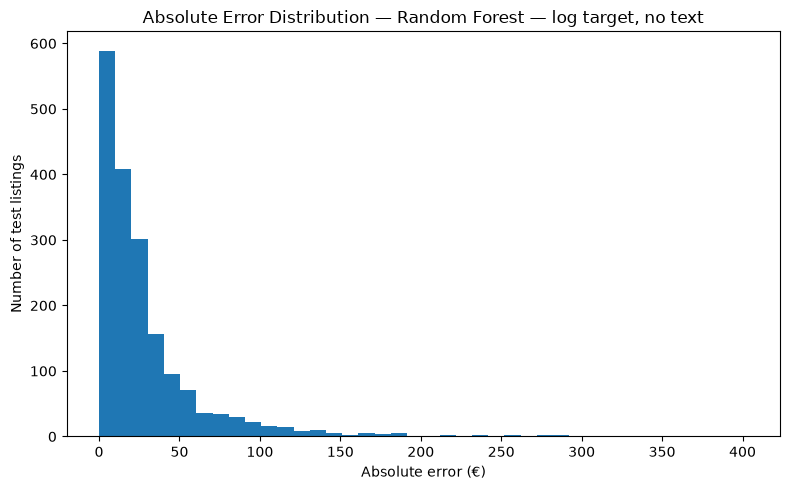

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(final_abs_error, bins=40)
ax.set_xlabel("Absolute error (€)")
ax.set_ylabel("Number of test listings")
ax.set_title(f"Absolute Error Distribution — {final_model_name}")
fig.tight_layout()
plt.show()

### Error by price band and room type

A €50 error is proportionally much more serious for a €70 listing than for a €500 listing. The following subgroup analysis therefore complements the global metrics. It is descriptive and should not be interpreted causally.

In [32]:
def reconstruct_room_type(frame):
    conditions = [
        frame["room_type_Hotel room"].eq(1),
        frame["room_type_Private room"].eq(1),
        frame["room_type_Shared room"].eq(1),
    ]
    choices = ["Hotel room", "Private room", "Shared room"]
    return np.select(conditions, choices, default="Entire home/apt")

error_frame = pd.DataFrame({
    "actual_price": y_test.to_numpy(),
    "predicted_price": final_pred,
    "absolute_error": final_abs_error,
    "room_type": reconstruct_room_type(X_test),
})
error_frame["price_quartile"] = pd.qcut(
    error_frame["actual_price"], q=4,
    labels=["Q1: lowest", "Q2", "Q3", "Q4: highest"],
    duplicates="drop",
)

price_band_errors = (
    error_frame.groupby("price_quartile", observed=False)
    .agg(
        n=("absolute_error", "size"),
        mae=("absolute_error", "mean"),
        median_ae=("absolute_error", "median"),
        within_25=("absolute_error", lambda s: np.mean(s <= 25)),
        within_50=("absolute_error", lambda s: np.mean(s <= 50)),
    )
    .reset_index()
)
room_type_errors = (
    error_frame.groupby("room_type")
    .agg(
        n=("absolute_error", "size"),
        mae=("absolute_error", "mean"),
        median_ae=("absolute_error", "median"),
        within_25=("absolute_error", lambda s: np.mean(s <= 25)),
        within_50=("absolute_error", lambda s: np.mean(s <= 50)),
    )
    .reset_index()
)

display(price_band_errors)
display(room_type_errors)

,price_quartile,n,mae,median_ae,within_25,within_50
0,Q1: lowest,481,14.527,11.026,0.811,0.973
1,Q2,437,17.979,13.884,0.771,0.959
2,Q3,459,23.695,18.903,0.627,0.908
3,Q4: highest,458,62.381,45.991,0.314,0.533


,room_type,n,mae,median_ae,within_25,within_50
0,Entire home/apt,1320,33.754,21.340,0.570,0.814
1,Hotel room,18,47.449,20.525,0.556,0.611
2,Private room,478,18.265,11.146,0.791,0.929
3,Shared room,19,7.883,5.723,0.947,1.000


### Permutation importance

Permutation importance measures the increase in test-set MAE when a feature is shuffled. It is more directly tied to predictive performance than impurity-based Random Forest importance, although correlated predictors can divide importance among themselves.

Because this diagnostic uses the test outcomes, it is reported only after model selection and is not used for additional feature selection.

,feature,importance_mean,importance_sd
0,minimum_nights,12.656,0.665
1,accommodates,10.235,0.403
2,room_type_Private room,6.205,0.374
3,bedrooms,6.036,0.439
4,distance_to_center_km,3.588,0.302
5,bathrooms_parsed,2.807,0.207
6,host_listings_count,2.052,0.098
7,instant_bookable,1.265,0.107
8,room_type_Shared room,1.244,0.100
9,host_total_listings_count,0.954,0.060


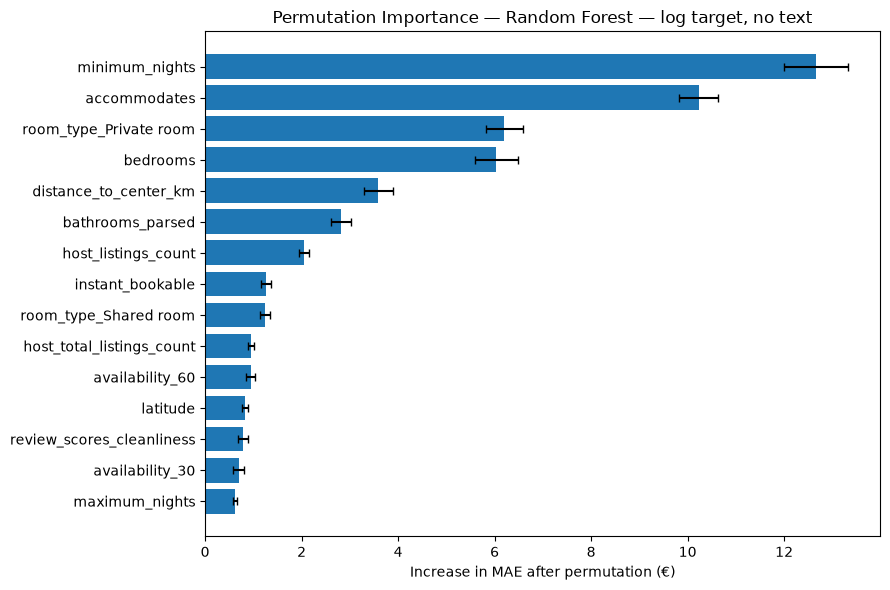

In [33]:
if final_model_name == "PyTorch MLP — log target, no text":
    rng = np.random.default_rng(RANDOM_STATE)
    baseline_mae = mean_absolute_error(y_test, final_pred)
    importance_rows = []
    for feature in X_test_final.columns:
        increases = []
        for _ in range(10):
            permuted = X_test_final.copy()
            permuted[feature] = rng.permutation(permuted[feature].to_numpy())
            prediction = predict_torch_mlp(final_model, permuted)
            increases.append(mean_absolute_error(y_test, prediction) - baseline_mae)
        importance_rows.append({
            "feature": feature,
            "importance_mean": np.mean(increases),
            "importance_sd": np.std(increases, ddof=1),
        })
    feature_importance = (
        pd.DataFrame(importance_rows)
        .sort_values("importance_mean", ascending=False)
        .reset_index(drop=True)
    )
else:
    perm = permutation_importance(
        final_model,
        X_test_final,
        y_test,
        scoring="neg_mean_absolute_error",
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
    feature_importance = (
        pd.DataFrame({
            "feature": X_test_final.columns,
            "importance_mean": perm.importances_mean,
            "importance_sd": perm.importances_std,
        })
        .sort_values("importance_mean", ascending=False)
        .reset_index(drop=True)
    )

display(feature_importance.head(15))

fig, ax = plt.subplots(figsize=(9, 6))
top = feature_importance.head(15).sort_values("importance_mean")
ax.barh(top["feature"], top["importance_mean"], xerr=top["importance_sd"], capsize=3)
ax.set_xlabel("Increase in MAE after permutation (€)")
ax.set_title(f"Permutation Importance — {final_model_name}")
fig.tight_layout()
plt.show()

### Gradient Boosting staged errors

These curves show how training and test MAE change as boosting stages are added. They are external MAE values, not incomparable internal objectives.

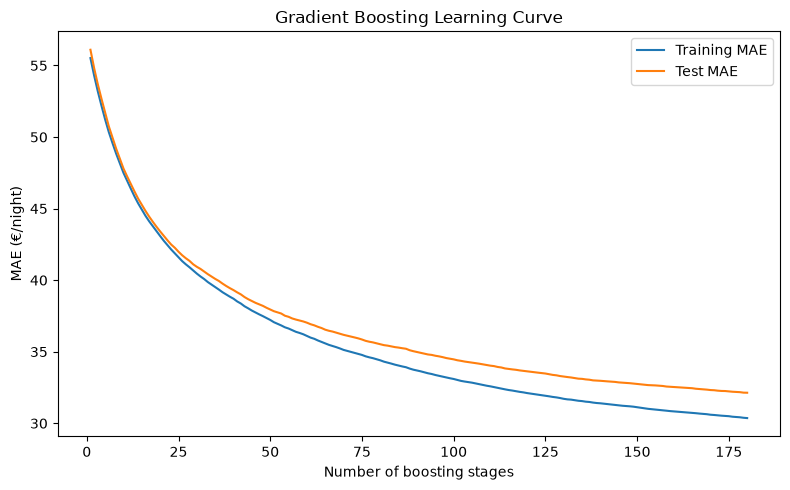

In [34]:
gbr_for_curve = fitted_models["Gradient Boosting — selected loss, full features"]
gbr_imputer = gbr_for_curve.named_steps["impute"]
gbr_estimator = gbr_for_curve.named_steps["model"]
X_train_gbr = gbr_imputer.transform(X_train)
X_test_gbr = gbr_imputer.transform(X_test)

train_stage_mae = [
    mean_absolute_error(y_train, prediction)
    for prediction in gbr_estimator.staged_predict(X_train_gbr)
]
test_stage_mae = [
    mean_absolute_error(y_test, prediction)
    for prediction in gbr_estimator.staged_predict(X_test_gbr)
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(train_stage_mae) + 1), train_stage_mae, label="Training MAE")
ax.plot(range(1, len(test_stage_mae) + 1), test_stage_mae, label="Test MAE")
ax.set_xlabel("Number of boosting stages")
ax.set_ylabel("MAE (€/night)")
ax.set_title("Gradient Boosting Learning Curve")
ax.legend()
fig.tight_layout()
plt.show()


### Bootstrap uncertainty for the final holdout predictions

Two intervals are reported for the fixed test predictions:

- a listing-level bootstrap, which treats listings as independent;
- a host-cluster bootstrap, which resamples complete hosts and is more conservative when listings from the same host are correlated.

These intervals describe uncertainty for the fixed prediction set. They do not include future market shift, target-scope uncertainty, or re-running the complete model-selection process.


In [35]:
def bootstrap_ci(
    y_true,
    y_pred,
    metric,
    n_boot=2000,
    confidence=0.95,
    seed=RANDOM_STATE,
):
    """Ordinary listing-level bootstrap for a fixed set of predictions."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    rng = np.random.default_rng(seed)
    values = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        values.append(metric(y_true[idx], y_pred[idx]))
    alpha = 1 - confidence
    return np.quantile(values, [alpha / 2, 1 - alpha / 2])


def cluster_bootstrap_ci(
    y_true,
    y_pred,
    clusters,
    metric,
    n_boot=2000,
    confidence=0.95,
    seed=RANDOM_STATE,
):
    """Bootstrap complete host clusters to allow within-host dependence."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    clusters = np.asarray(clusters)
    unique_clusters = np.unique(clusters)
    cluster_indices = {
        cluster: np.flatnonzero(clusters == cluster)
        for cluster in unique_clusters
    }

    rng = np.random.default_rng(seed)
    values = []
    for _ in range(n_boot):
        sampled_clusters = rng.choice(
            unique_clusters,
            size=len(unique_clusters),
            replace=True,
        )
        idx = np.concatenate([cluster_indices[cluster] for cluster in sampled_clusters])
        values.append(metric(y_true[idx], y_pred[idx]))

    alpha = 1 - confidence
    return np.quantile(values, [alpha / 2, 1 - alpha / 2])


metric_functions = {
    "MAE": mean_absolute_error,
    "RMSE": lambda actual, predicted: mean_squared_error(actual, predicted) ** 0.5,
}
bootstrap_rows = []
for metric_name, metric_function in metric_functions.items():
    listing_ci = bootstrap_ci(y_test, final_pred, metric_function)
    host_ci = cluster_bootstrap_ci(
        y_test,
        final_pred,
        hosts_test,
        metric_function,
    )
    estimate = metric_function(y_test, final_pred)
    bootstrap_rows.extend([
        {
            "metric": metric_name,
            "bootstrap_unit": "listing",
            "estimate": estimate,
            "ci_2.5%": listing_ci[0],
            "ci_97.5%": listing_ci[1],
        },
        {
            "metric": metric_name,
            "bootstrap_unit": "host cluster",
            "estimate": estimate,
            "ci_2.5%": host_ci[0],
            "ci_97.5%": host_ci[1],
        },
    ])

bootstrap_intervals = pd.DataFrame(bootstrap_rows)
display(bootstrap_intervals)


,metric,bootstrap_unit,estimate,ci_2.5%,ci_97.5%
0,MAE,listing,29.586,27.886,31.430
1,MAE,host cluster,29.586,27.669,31.646
2,RMSE,listing,49.244,45.081,53.668
3,RMSE,host cluster,49.244,44.867,53.817


## 15. Reproducibility summary

The executed notebook embeds all principal tables and figures. It also writes a compact local result bundle used by `04_final_results.ipynb`, preventing copied numbers from becoming inconsistent. Exact package versions are recorded because neural-network results can vary slightly across software versions even with deterministic seeds.

In [36]:
environment_summary = pd.DataFrame({
    "package": ["Python", "NumPy", "pandas", "scikit-learn", "PyTorch"],
    "version": [
        platform.python_version(),
        np.__version__,
        pd.__version__,
        sklearn.__version__,
        torch.__version__,
    ],
})

reproducibility_summary = pd.DataFrame({
    "item": [
        "Random state",
        "Holdout test fraction",
        "Repeated-holdout seeds",
        "Cross-validation folds",
        "Numeric imputation",
        "Best Ridge alpha",
        "Best Random Forest parameters",
        "Best Gradient Boosting structure",
        "Best Gradient Boosting loss",
        "Selected MLP architecture",
        "Selected final candidate",
    ],
    "value": [
        RANDOM_STATE,
        TEST_SIZE,
        STABILITY_SEEDS,
        N_CV_SPLITS,
        "Median fitted inside each training split/fold",
        ridge_search.best_params_["model__alpha"],
        best_rf_parameters,
        best_gbr_structure,
        best_gbr_loss,
        selected_mlp_architecture,
        selected_candidate_name,
    ],
})
display(environment_summary)
display(reproducibility_summary)


,package,version
0,Python,3.14.0
1,NumPy,2.5.0
2,pandas,3.0.3
3,scikit-learn,1.9.0
4,PyTorch,2.13.0+cpu


,item,value
0,Random state,42
1,Holdout test fraction,0.200
2,Repeated-holdout seeds,"[0, 21, 42, 84, 123]"
3,Cross-validation folds,3
4,Numeric imputation,Median fitted inside each training split/fold
5,Best Ridge alpha,10.000
6,Best Random Forest parameters,"{'max_depth': 20, 'max_features': 0.7, 'min_sa..."
7,Best Gradient Boosting structure,"{'learning_rate': 0.05, 'max_depth': 3, 'min_s..."
8,Best Gradient Boosting loss,huber
9,Selected MLP architecture,PyTorch MLP 128-64-32


### Synchronized result bundle for Notebook 04

The JSON file below is generated locally under `data/processed/` and is ignored by Git together with the other processed data. Notebook 04 reads this file when rerun, while its saved notebook outputs remain visible on GitHub.

In [37]:
def dataframe_records(frame: pd.DataFrame) -> list[dict]:
    # pandas handles NumPy scalar conversion and missing values reliably here.
    return json.loads(frame.to_json(orient="records"))


selected_stability_row = selected_candidate_stability.rename(
    columns={"candidate": "model"}
)
report_stability = pd.concat(
    [
        selected_stability_row,
        stability_summary.loc[
            stability_summary["model"].isin([
                MLP_CANDIDATE_NAME,
                "Random Forest — raw target, full features",
                "Gradient Boosting — selected loss, full features",
                "Linear Regression",
                "Ridge — raw target, full features",
            ])
        ],
    ],
    ignore_index=True,
).drop_duplicates(subset=["model"], keep="first")
report_stability = report_stability.sort_values("mean_mae").reset_index(drop=True)

result_bundle = {
    "metadata": {
        "selected_model": selected_candidate_name,
        "selected_mlp_architecture": selected_mlp_architecture,
        "mlp_best_epoch": int(mlp_best_epoch),
        "mlp_history_scope": mlp_main_artifacts["history_scope"],
        "random_state": RANDOM_STATE,
        "test_size": TEST_SIZE,
        "cv_folds": N_CV_SPLITS,
        "n_training": int(len(y_train)),
        "n_test": int(len(y_test)),
        "n_unique_hosts": int(host_groups.nunique()),
        "numeric_imputation": "median fitted inside each training split/fold",
        "python_version": platform.python_version(),
        "numpy_version": np.__version__,
        "pandas_version": pd.__version__,
        "sklearn_version": sklearn.__version__,
        "torch_version": torch.__version__,
    },
    "tables": {
        "model_comparison": dataframe_records(model_comparison_final),
        "candidate_cv": dataframe_records(final_candidate_cv),
        "final_holdout_predictions": dataframe_records(final_holdout_predictions),
        "mlp_history": dataframe_records(mlp_history),
        "mlp_architecture_summary": dataframe_records(mlp_architecture_summary),
        "stability": dataframe_records(report_stability),
        "host_generalization_runs": dataframe_records(host_generalization_runs),
        "host_generalization_summary": dataframe_records(host_generalization_summary),
        "loss_comparison": dataframe_records(loss_comparison),
        "spatial_ablation": dataframe_records(spatial_ablation),
        "text_ablation": dataframe_records(text_ablation),
        "price_band_errors": dataframe_records(price_band_errors),
        "room_type_errors": dataframe_records(room_type_errors),
        "feature_importance": dataframe_records(feature_importance.head(15)),
        "bootstrap_intervals": dataframe_records(bootstrap_intervals),
        "residual_bin_summary": dataframe_records(residual_bin_summary),
        "calibration_by_decile": dataframe_records(calibration_by_decile),
    },
}

RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
with RESULTS_PATH.open("w", encoding="utf-8") as handle:
    json.dump(result_bundle, handle, indent=2, ensure_ascii=False)

print("Saved synchronized results to:", RESULTS_PATH)


Saved synchronized results to: C:\Personal Documents\Masters\Semester 2\Machine_Learning\airbnb-price-prediction-berlin\data\processed\final_results.json


## 16. Scientific interpretation and self-critique

### What the results can support

- Predictive comparisons among the tested models for listings drawn from approximately the same in-scope Berlin snapshot distribution.
- Whether spatial information and the current simple text-derived features improve repeated-holdout prediction.
- Whether a compact, regularized PyTorch MLP is competitive with the classical tabular models under the same primary metric.
- A secondary estimate of how performance changes when test hosts are absent from training.

### Modalities and final feature choice

The project evaluates three modalities: tabular, spatial, and text-derived information. The six text-derived length and word-count variables did not improve the Random Forest's training-based validation performance, so the selected model retains tabular and spatial predictors only. This is evidence-based feature selection; it does not imply that semantic listing text is uninformative, because TF-IDF and language embeddings were not tested.

### Important model and metric trade-offs

The final candidate is selected by training-only cross-validated MAE. Its RMSE and R² can be worse than those of a raw-target model because reducing typical absolute euro error does not necessarily minimize large upper-tail errors. The final choice is therefore metric-dependent rather than universally superior.

The original-price residual spread increases with predicted price, and the highest actual-price quartile has much larger absolute errors than the lower quartiles. This is a calibration and unequal-error-risk limitation, not a violation that invalidates Random Forest fitting. The nonnegative price scale also imposes the geometric boundary `residual >= -prediction`. The log-scale diagnostic is included because the model was trained on `log1p(price)` and relative errors are more stable than absolute euro errors.

### What the results cannot support

- Causal claims about why a feature changes price.
- Generalization to other cities, future Airbnb markets, missing-price listings, or the removed extreme upper tail.
- Semantic conclusions about listing text, because only lengths and word counts were modeled.
- A fully independent unseen-host benchmark: the grouped analysis is a secondary stress test of a configuration selected in the primary workflow.
- Uniform precision across price ranges; expensive listings have substantially larger errors and should be interpreted cautiously.

### Weakest methodological choice

The study population was restricted using a 99th-percentile target cutoff computed during EDA, and one-hot columns were defined before splitting. Training-only imputation in this notebook removes the main full-data fill-value leakage, but the target-scope decision still means that reported performance applies only to the retained price range.

### Selection-estimate limitation

The compact hyperparameter searches and final candidate comparison reuse the same training cross-validation folds. Their cross-validation scores can therefore be mildly optimistic after selection. The fixed test set remains untouched until the candidate is chosen, but a larger study would use nested cross-validation.

### Most likely implementation failure guarded against

Part 2 represented missing `host_is_superhost` values as `"Unknown"` while its original binary map listed lowercase `"unknown"`. Notebook 2 now recognizes both spellings, and Notebook 3 independently reconstructs the missing state before training-only imputation. Explicit feature lists also prevent `id` or `host_id` from entering the predictors.

### Strongest alternative explanation

Spatial gains may reflect correlated property types, room types, host behavior, or market segmentation concentrated in particular areas rather than a direct causal effect of location.

### Remaining practical uncertainty

A €50 error is not necessarily equally serious at every listing price. MAE, RMSE, threshold accuracy, price-band errors, raw-versus-log target comparisons, alternative losses, and the calibration-by-decile diagnostic expose this trade-off, but the project has no external business cost function defining the exact economic value of each error. Prediction intervals or quantile models would be a useful future extension for communicating listing-specific uncertainty.